# **Import libraries and dataset**

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, average_precision_score, f1_score, PrecisionRecallDisplay, roc_auc_score
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import time
import logging
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials


from eda_data_visualization import plot_categorical_vs_target, plot_continuous_vs_target
from preprocess_data import preprocess_bank_data
from evaluate_model import predict_and_plot

In [ ]:
raw_df = pd.read_csv('bank-additional-full.csv', sep=';')

In [ ]:
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# **Exploratory Data Analysis**

In [ ]:
raw_df.shape

(41188, 21)

In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
raw_df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [ ]:
raw_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
raw_df['y'] = raw_df['y'].map({'yes': 1, 'no': 0})

In [ ]:
raw_df['y'].value_counts()

,count
y,
0,36548
1,4640


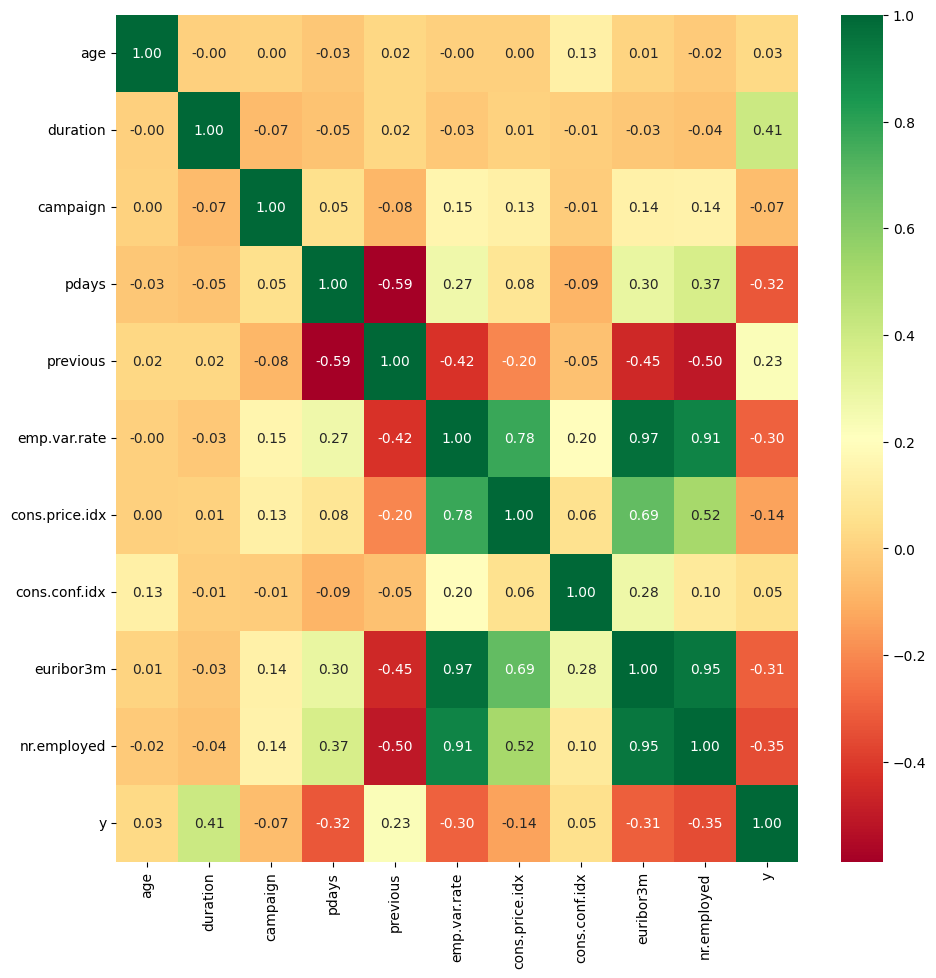

In [ ]:
corr_df = raw_df.select_dtypes(include=["int64","float64"]).corr()


corr_df.shape

plt.figure(figsize = (11,11))
sns.heatmap(data = corr_df, annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show();

In [ ]:
input_cols = list(raw_df.drop(columns='y').columns)
target_col = 'y'


inputs = raw_df[input_cols].copy()
targets = raw_df[target_col].copy()

train_df, val_df = train_test_split(raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df['y']
)

numeric_cols = inputs.select_dtypes('number').columns.tolist()
categorical_cols = inputs.select_dtypes('object').columns.tolist()


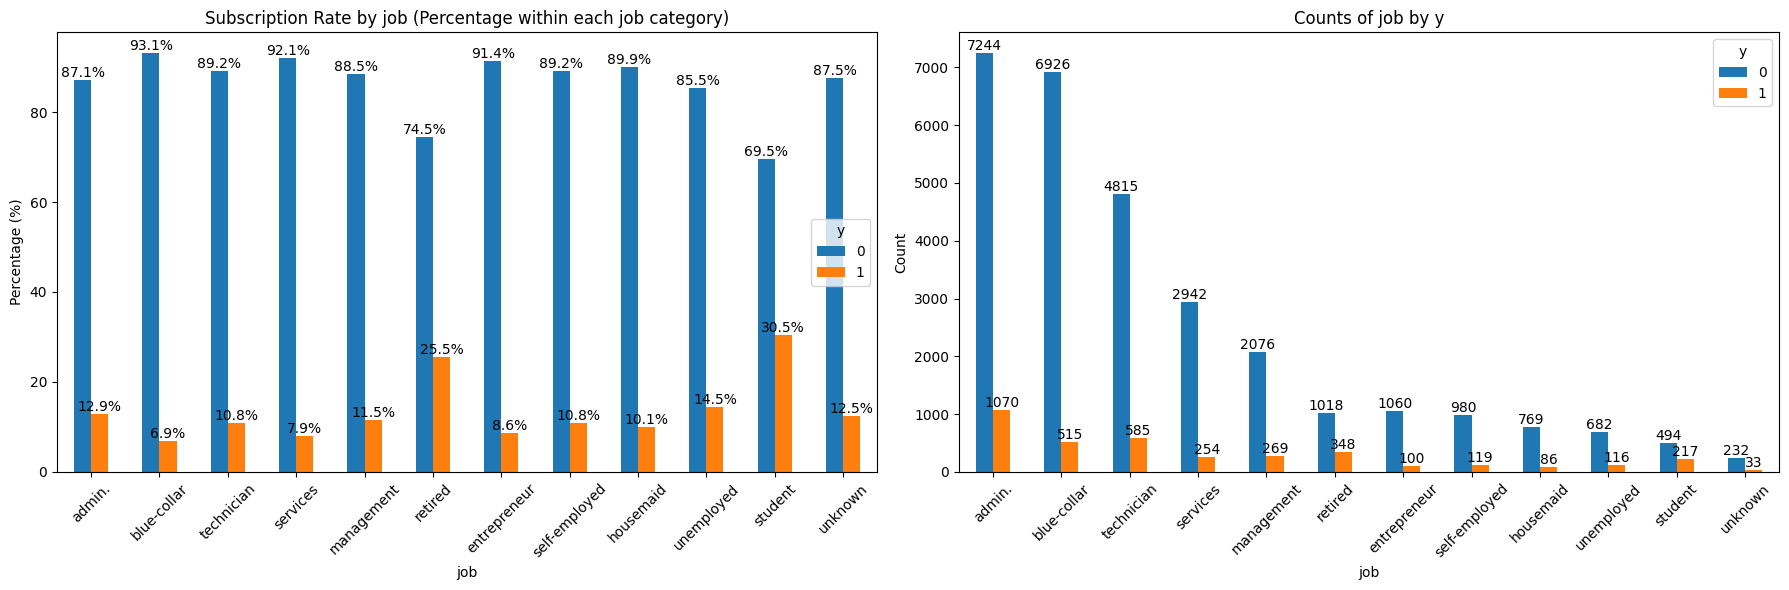

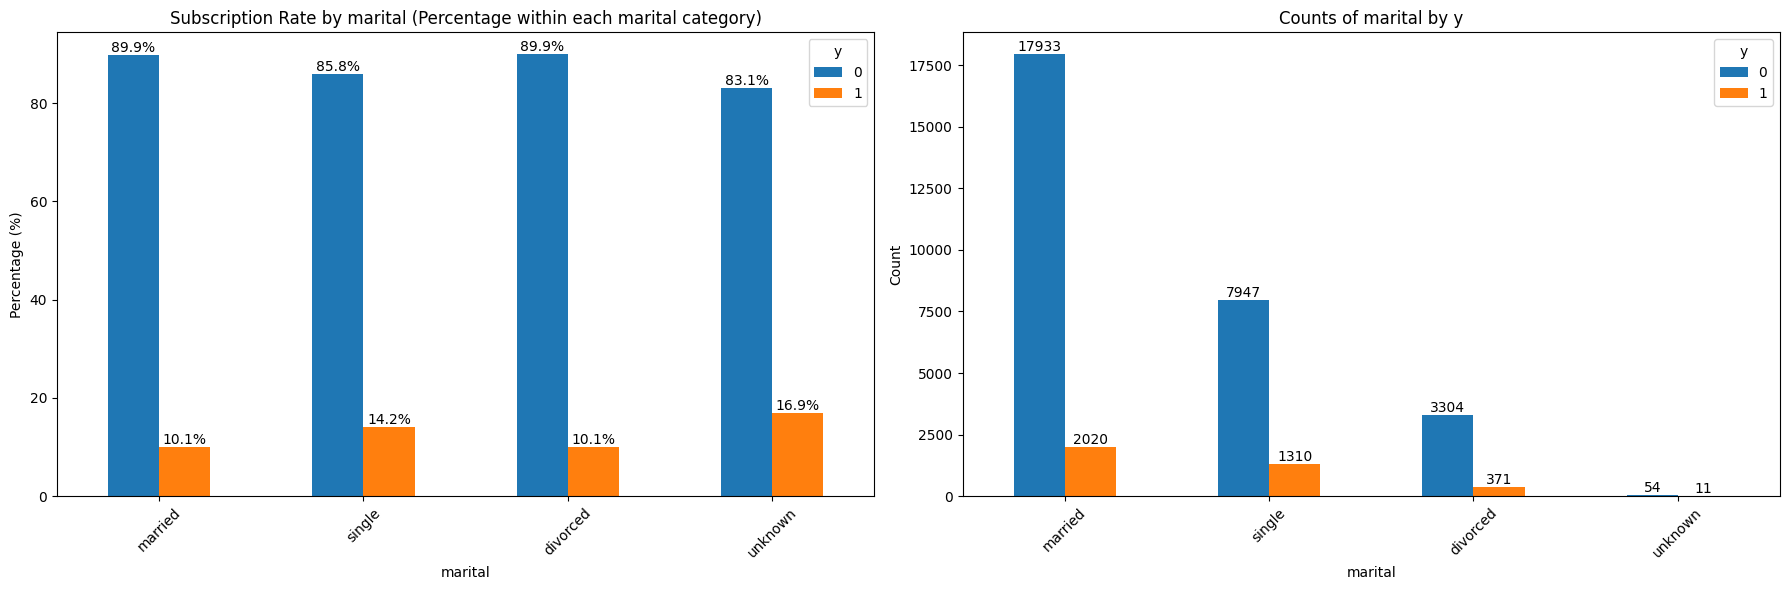

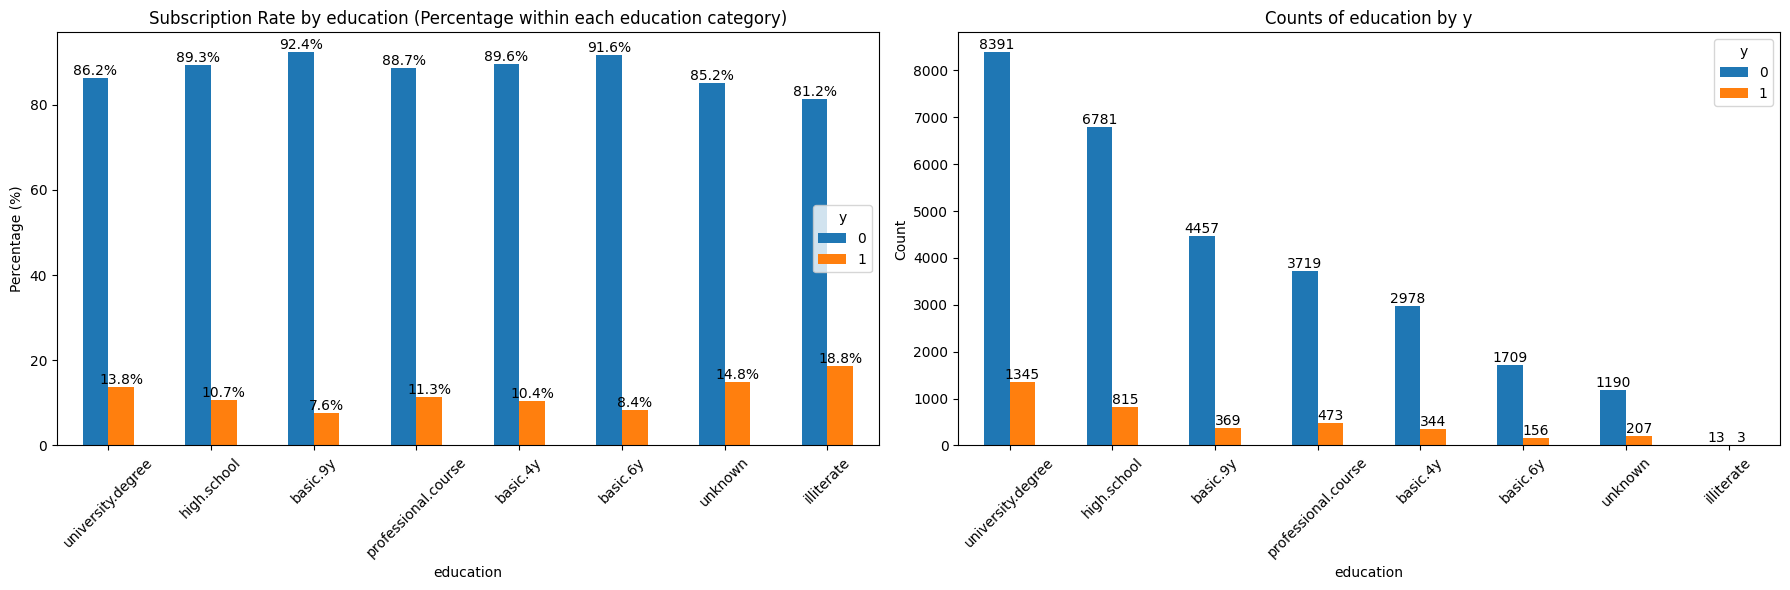

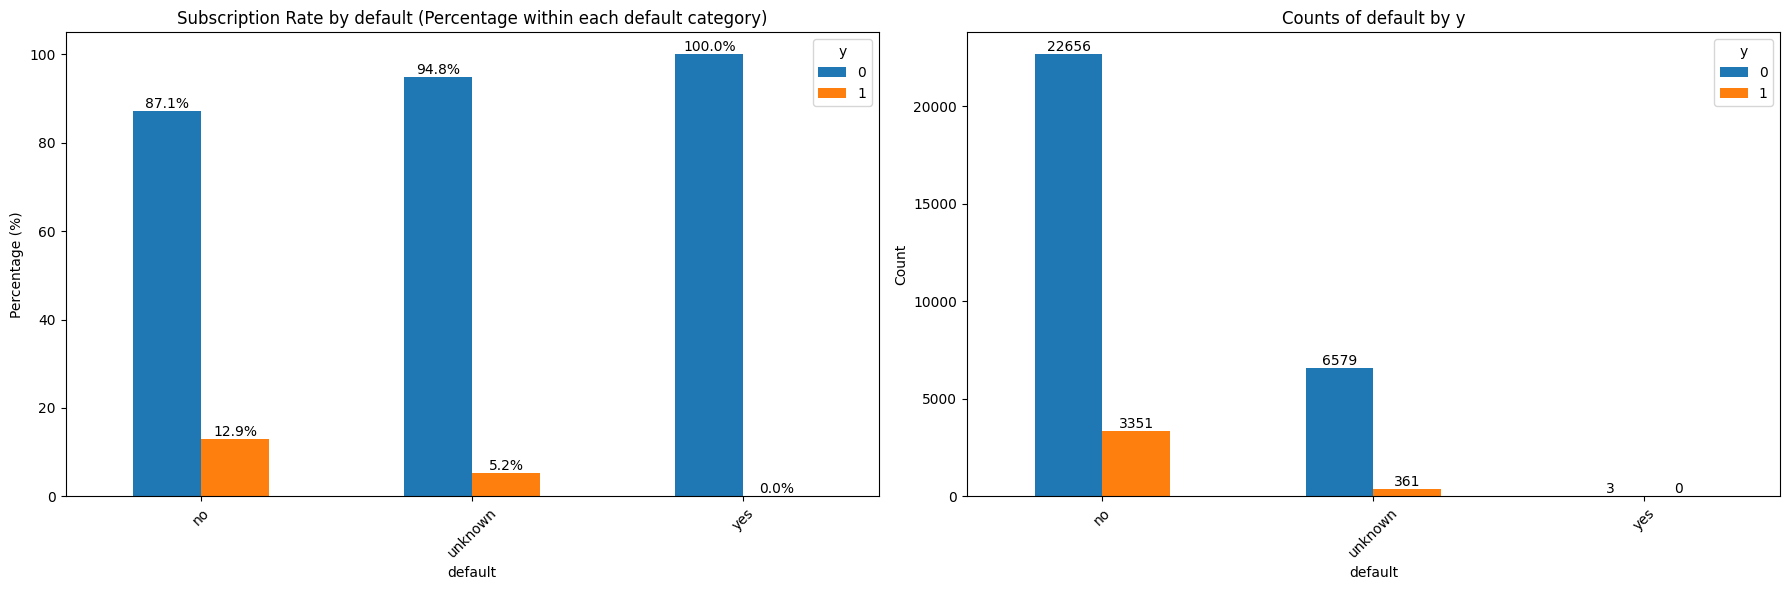

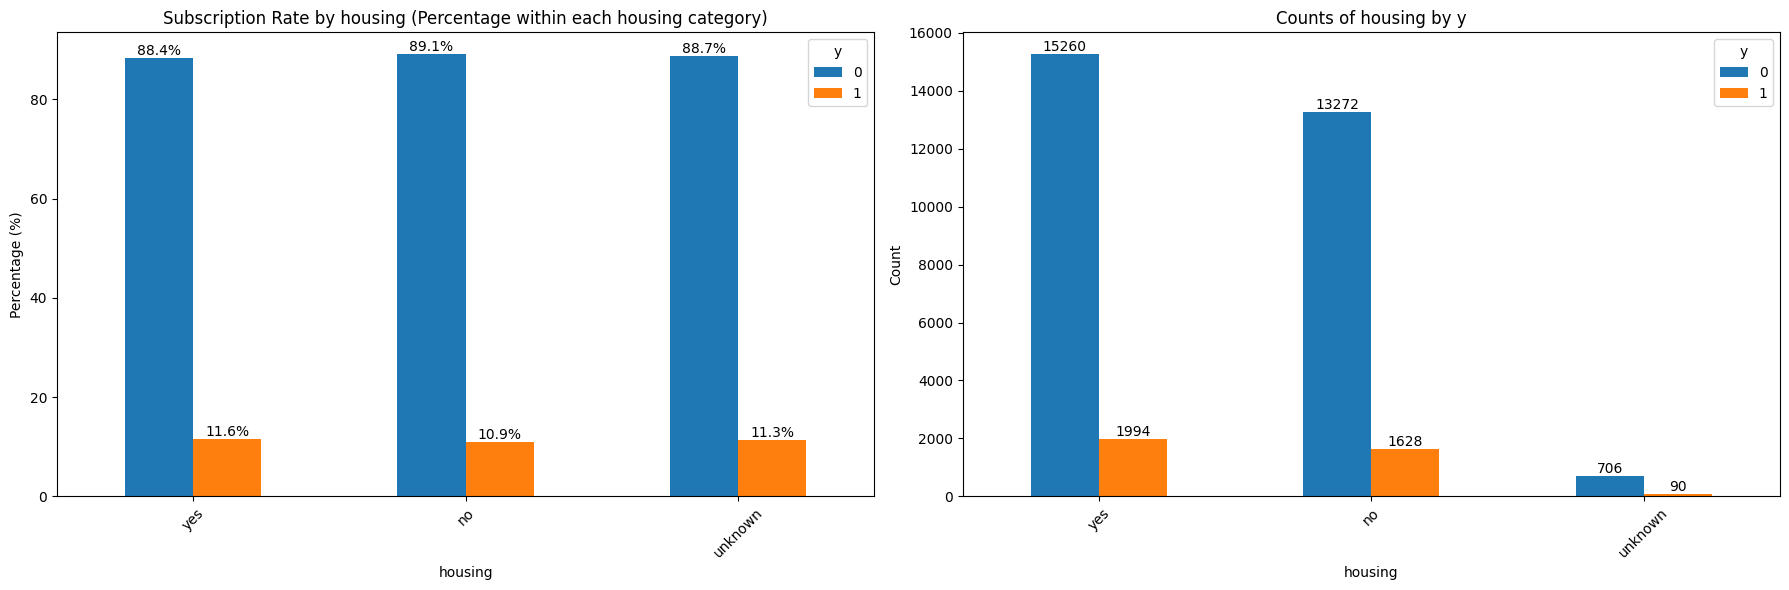

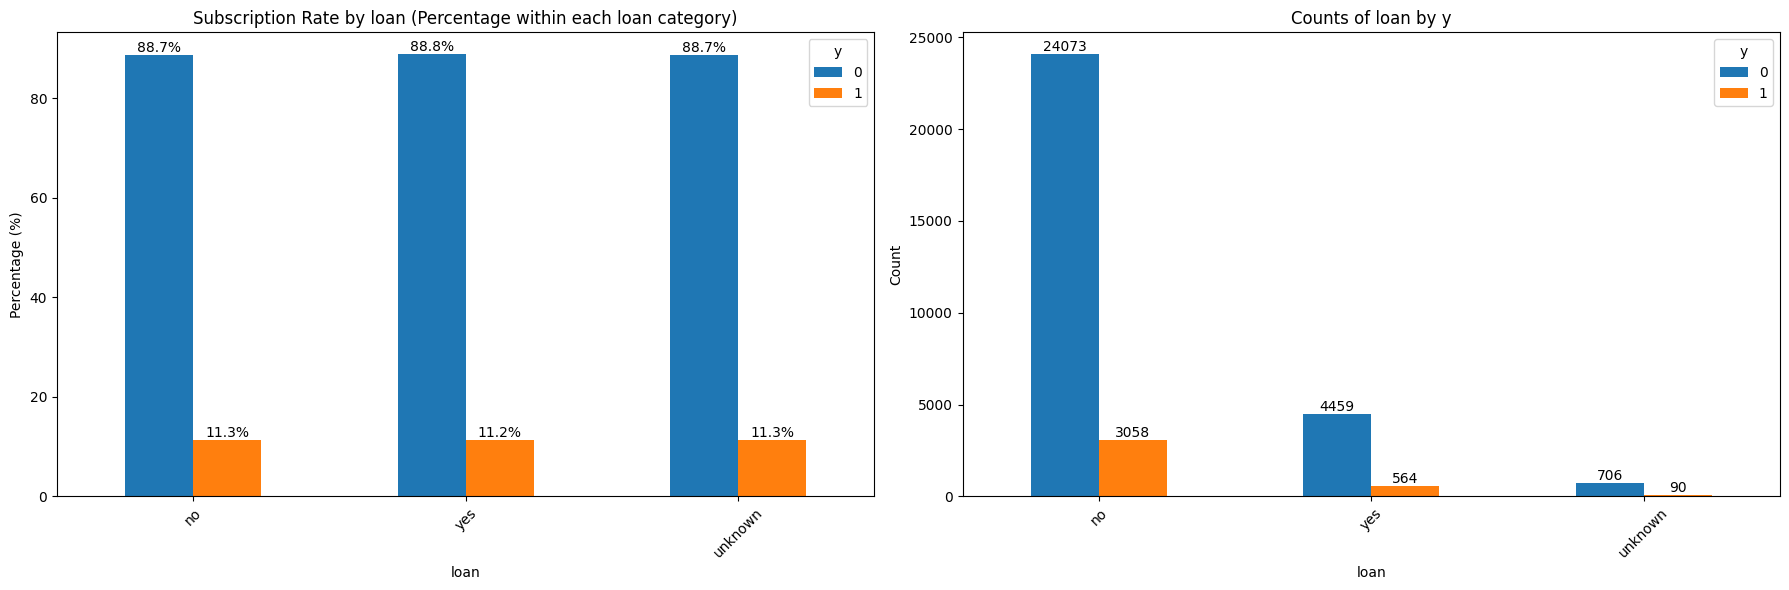

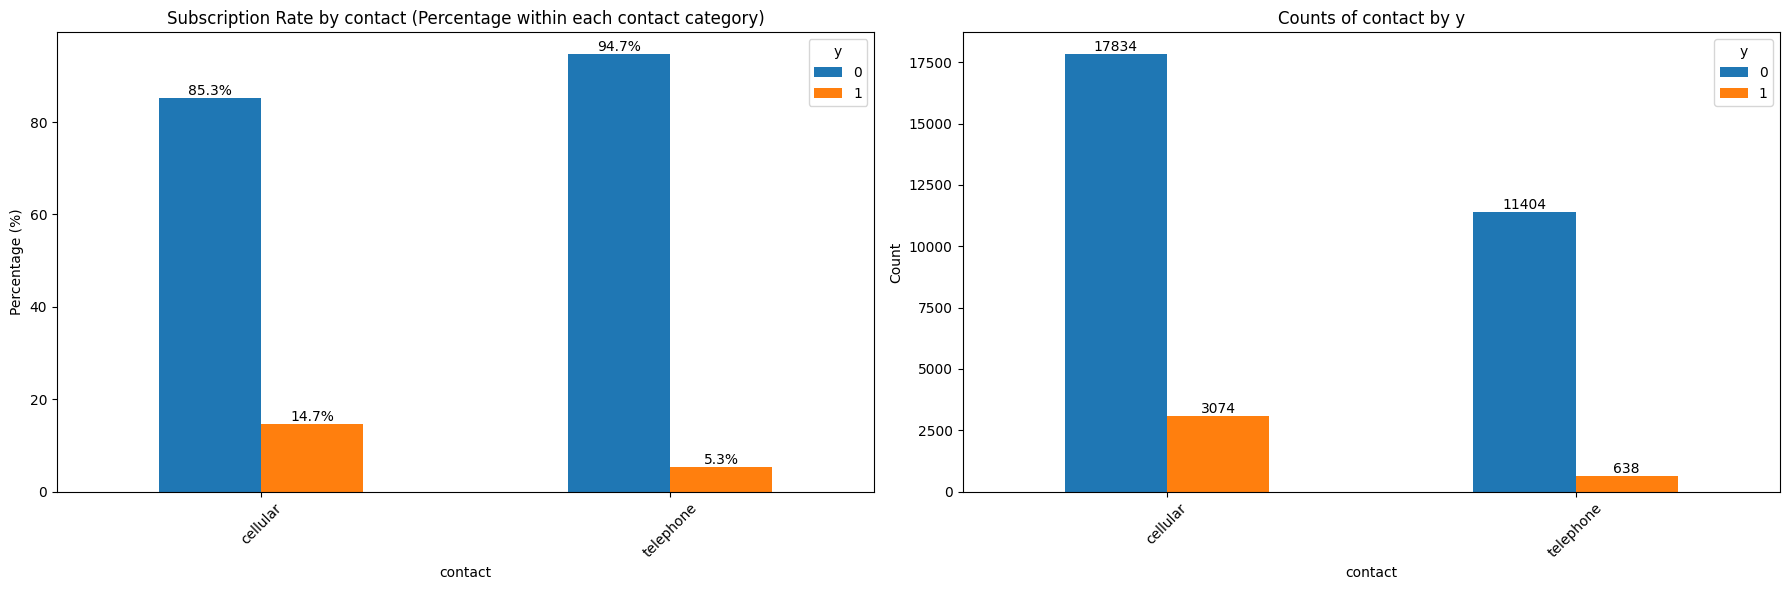

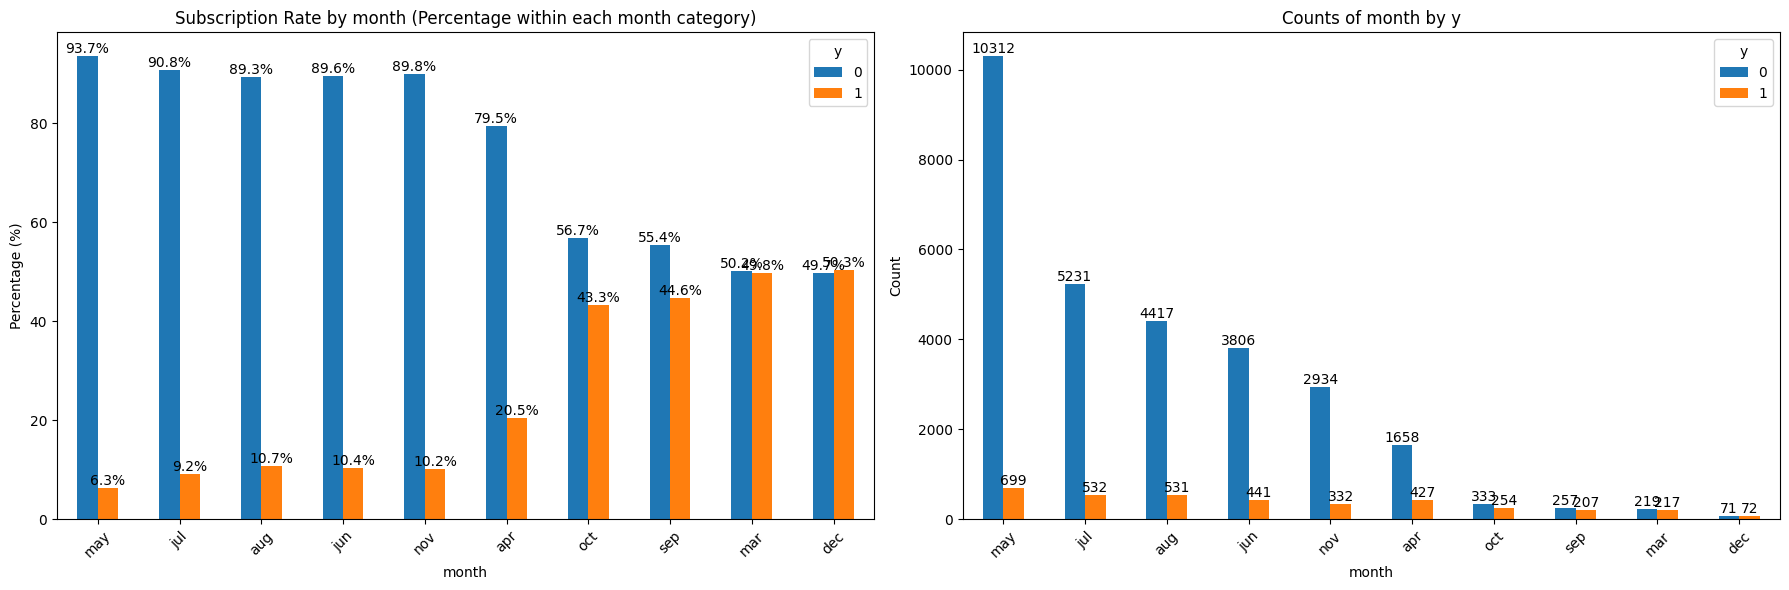

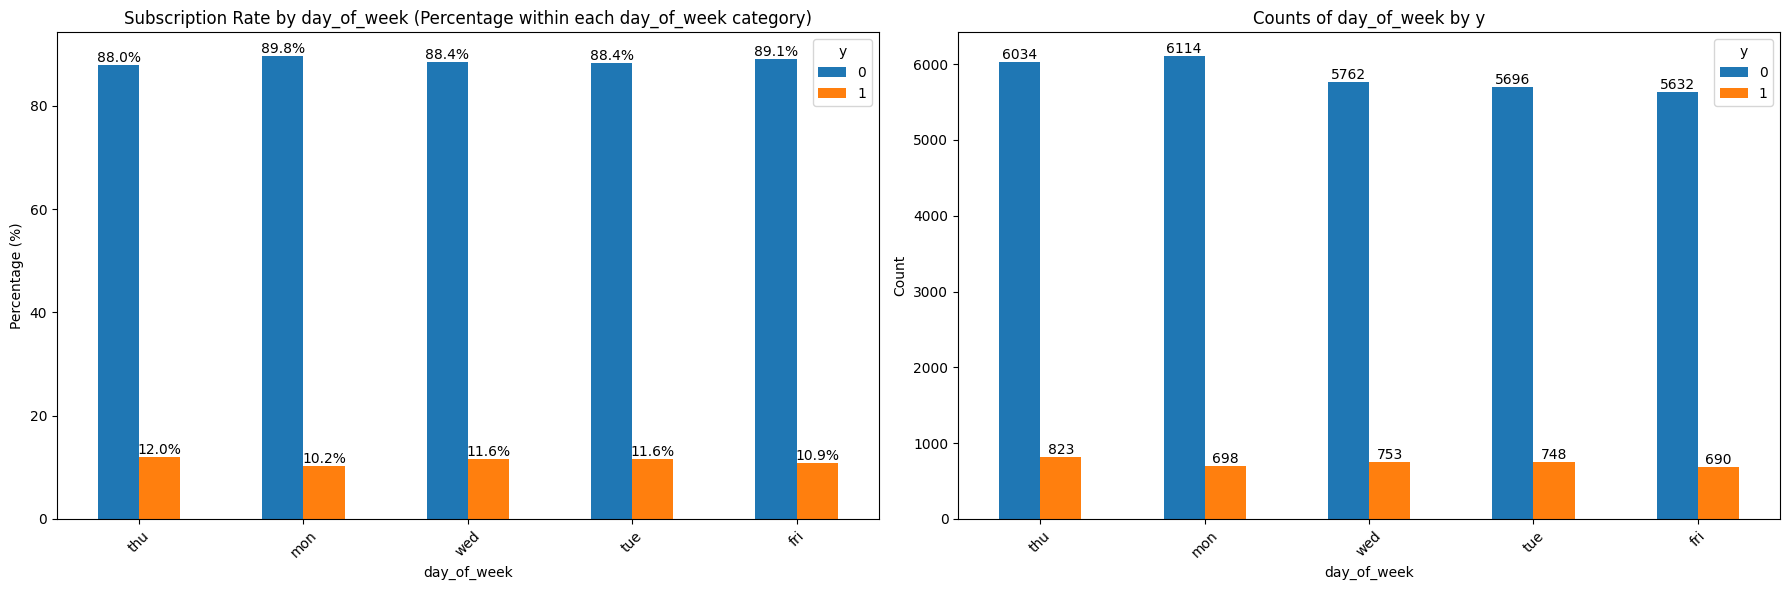

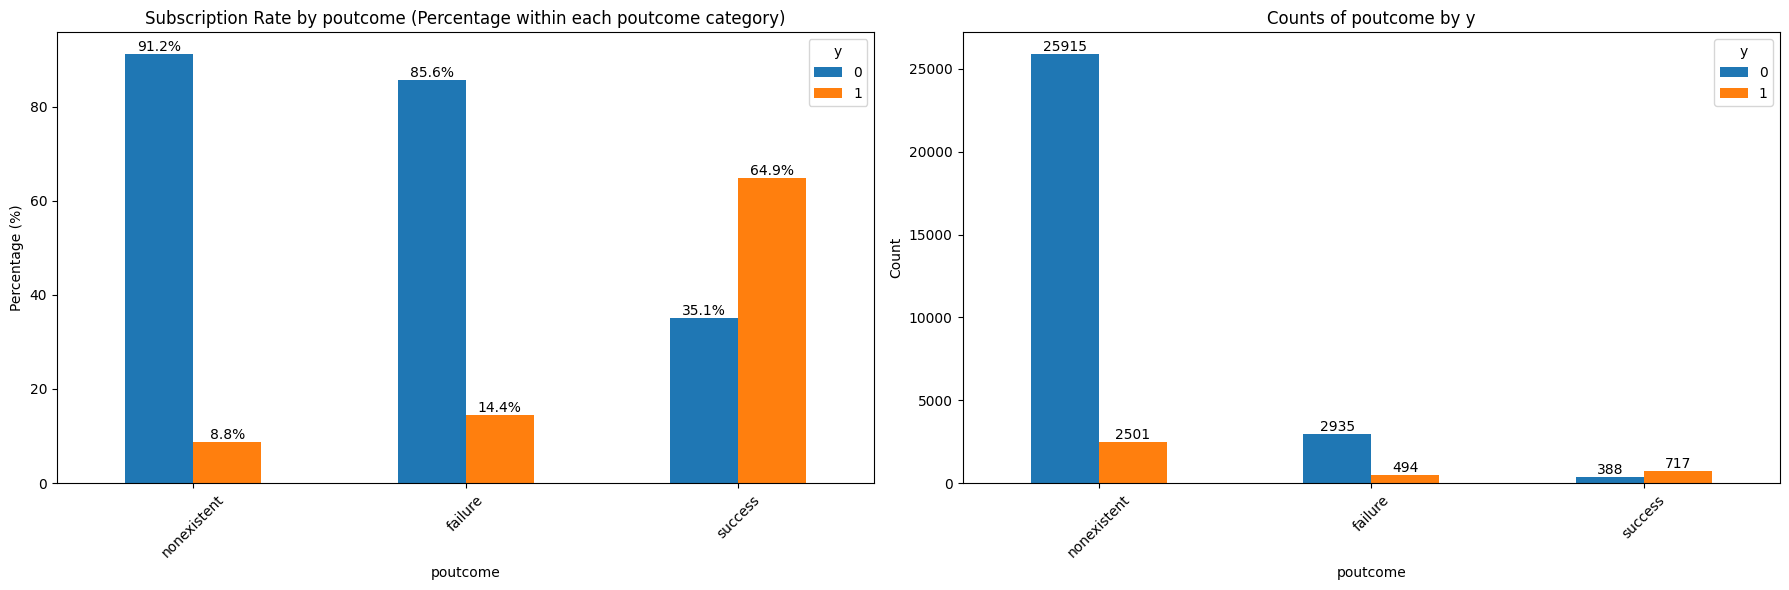

In [ ]:
#EDA for categorial variables
for col in categorical_cols:
  plot_categorical_vs_target(train_df, col, 'y')

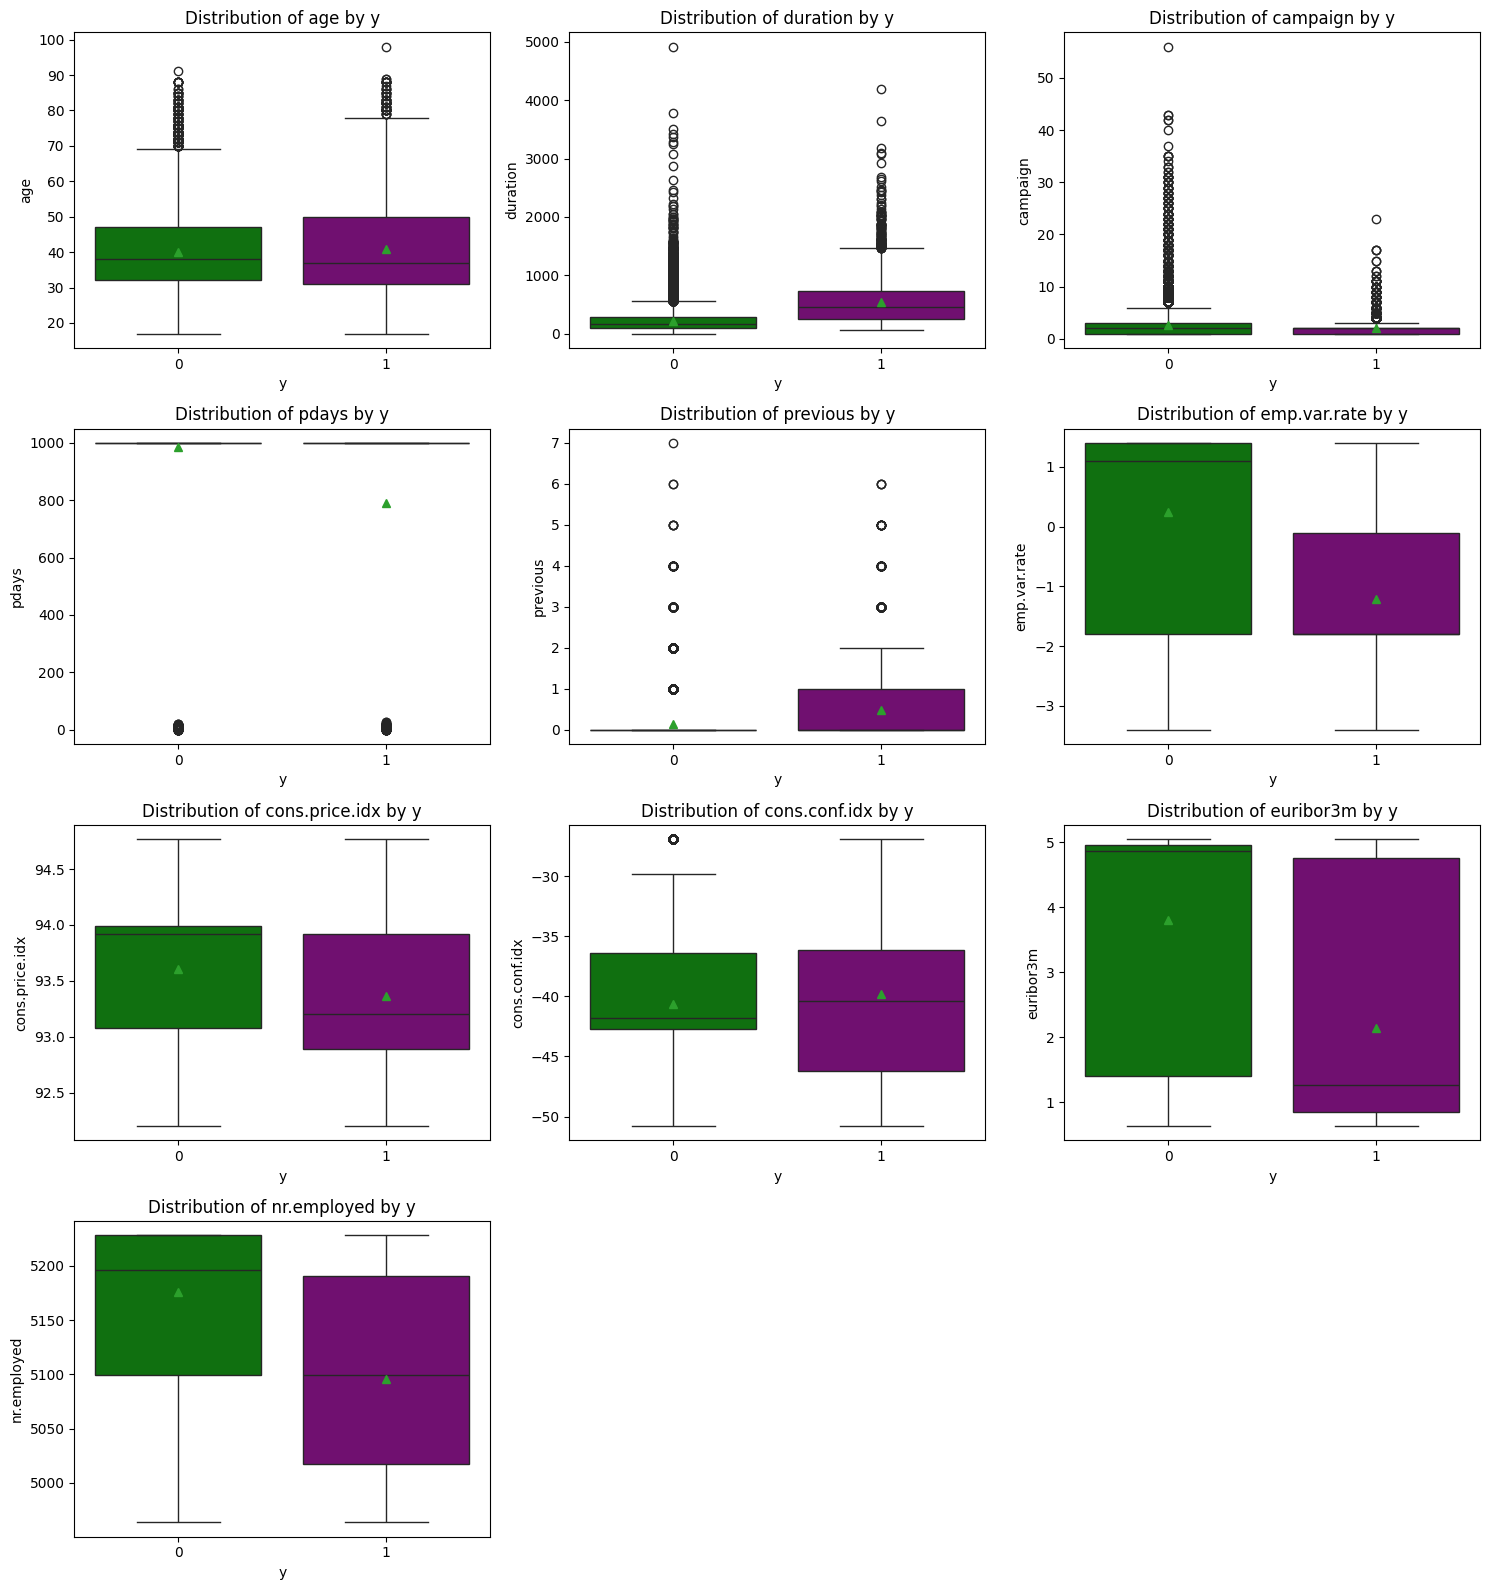

In [ ]:
#EDA for continuous variables without outlier detection
custom_palette = {0: 'green', 1: 'purple'}
plot_continuous_vs_target(train_df, numeric_cols, palette=custom_palette, remove_outliers=False)

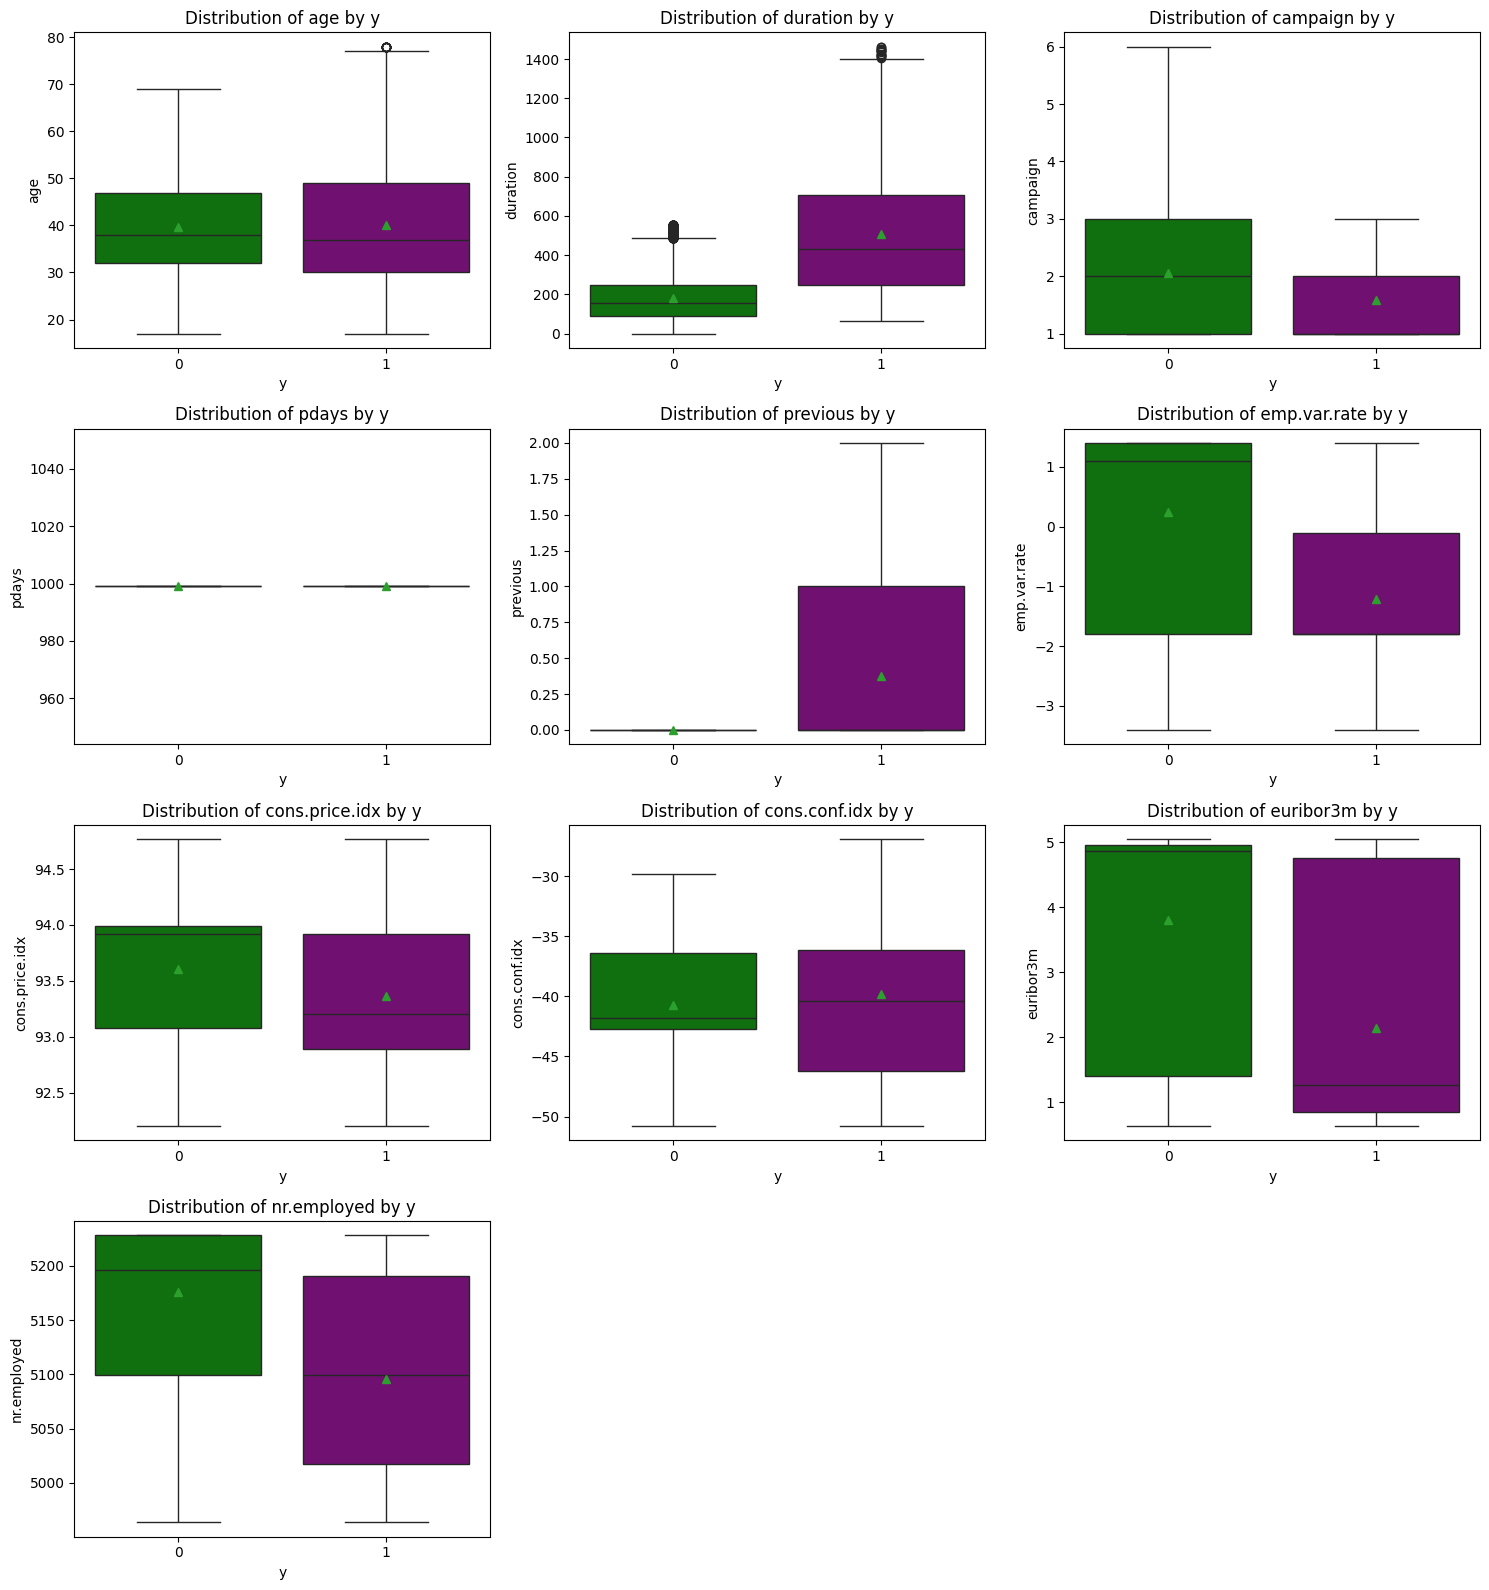


--- Outlier Removal Report (1.5*IQR method, for plotting purposes) ---
Column: 'age'
  - Target '0': Removed 196 outliers from 29238 instances (0.67%).
  - Target '1': Removed 63 outliers from 3712 instances (1.70%).
Column: 'duration'
  - Target '0': Removed 1736 outliers from 29238 instances (5.94%).
  - Target '1': Removed 112 outliers from 3712 instances (3.02%).
Column: 'campaign'
  - Target '0': Removed 1827 outliers from 29238 instances (6.25%).
  - Target '1': Removed 444 outliers from 3712 instances (11.96%).
Column: 'pdays'
  - Target '0': Removed 446 outliers from 29238 instances (1.53%).
  - Target '1': Removed 780 outliers from 3712 instances (21.01%).
Column: 'previous'
  - Target '0': Removed 3323 outliers from 29238 instances (11.37%).
  - Target '1': Removed 145 outliers from 3712 instances (3.91%).
Column: 'emp.var.rate'
  - Target '0': Removed 0 outliers from 29238 instances (0.00%).
  - Target '1': Removed 0 outliers from 3712 instances (0.00%).
Column: 'cons.price

In [ ]:
#EDA for continuous variables with outlier detection
custom_palette = {0: 'green', 1: 'purple'}
plot_continuous_vs_target(train_df, numeric_cols, palette=custom_palette, remove_outliers=True)

### Key Findings from Exploratory Data Analysis

### Continuous variables

*   **`duration` (Duration of last contact in seconds)**: This variable showed the most significant distinction, with subscribers ($y=1$) having a dramatically higher median and wider distribution for contact duration compared to non-subscribers ($y=0$). Even after removing moderate percentages of outliers (5.94% for $y=0$ and 3.02% for $y=1$), the stark difference persisted, reinforcing its strong correlation with subscription.While `duration` is a strong predictor, it represents data leakage for predictive models before a call concludes - therefore we will not use this input variable for prediction.

*   **Economic Indicators**:
    *   **`euribor3m`** is significantly lower for subscribers (mean: 2.14) than for non-subscribers (mean: 3.81). This is a strong indicator that lower interest rates make term deposits more attractive.
    *   **`emp.var.rate`**: Subscribers (y=1) tend to be associated with a lower `emp.var.rate` (mean: -1.04) compared to non-subscribers (mean: 0.17). This indicates that clients are more likely to subscribe during periods of lower economic uncertainty or improving employment conditions.
    *   **`cons.conf.idx`**: The `cons.conf.idx` is notably higher for subscribers (mean: -39.79) compared to non-subscribers (mean: -40.61). Higher consumer confidence usually implies a more positive economic outlook, making people more willing to invest.
    *   For most economic indicators, outlier percentages were low, indicating that the observed distributional shifts are representative of the general population and not driven by extreme values.
*   **`pdays` (Days since last contact from a previous campaign)**: is lower for subscribers (excluding 999). The `pdays` variable has a special value of 999 indicating that the client was not previously contacted. The mean `pdays` for subscribers (793.18) is lower than for non-subscribers (970.52). This indicates that clients who were contacted more recently in a previous campaign (i.e., `pdays` < 999) are more likely to subscribe. The 25th and 75th percentiles are still 999 for non-subscribers, suggesting that a large portion of them were never contacted before. However, the median `pdays` for subscribers is 999, indicating that even among subscribers, many were first-time contacts.
*   **`campaign` (Number of contacts during this campaign)**: Clients who subscribed (y=1) generally had fewer contacts during the current campaign (mean: 2.06, median: 2.0) than those who did not (mean: 2.61, median: 2.0). This suggests that excessive campaigning might not be effective and could even be counterproductive, or that successful conversions happen earlier. A higher percentage of outliers was removed for subscribers ($y=1$, 11.96%) than non-subscribers ($y=0$, 6.25%).
*   **`previous` (Number of contacts before this campaign)**: Subscribers (y=1) had a higher mean number of previous contacts (0.49) compared to non-subscribers (0.15). This suggests that clients who have been contacted before (and not necessarily subscribed) are more receptive in the current campaign.
*   **`age`**: Subscribers ($y=1$) had a slightly higher median age. Outlier removal percentages were low for both groups (0.67% for $y=0$ and 1.70% for $y=1$), indicating age differences are not heavily influenced by extreme values.

### Categorical variables

*   **`job`**: `student` and `retired` categories show significantly higher subscription rates (around 30-31%) compared to the overall average. `blue-collar` and `services` jobs have the lowest subscription rates (below 10%). `admin.` is the most frequent job type, with a subscription rate slightly above average. The `unknown` job category has a moderate subscription rate, but its relatively small count suggests limited impact.

*   **`marital`**: `single` individuals have a noticeably higher subscription rate (around 14%) compared to `married` (around 10%) and `divorced` (around 10%). `married` individuals represent the largest group. The `unknown` category has a very low count and a low subscription rate.

*   **`education`**: Clients with `university.degree` and `professional.course` show higher subscription rates (around 13-14%) than those with `basic` education levels (e.g., `basic.4y` at ~10%, `basic.9y` at ~7%). `illiterate` clients have a very high subscription rate but represent a tiny fraction of the dataset, making it a less reliable indicator due to low counts. The `unknown` education level has a low subscription rate.

*   **`default`**: This feature shows a strong distinction. Clients with `no` default have a significantly higher subscription rate (around 14%) than those with `yes` default (which is negligible at ~0%). A large proportion of clients have an `unknown` default status (over 20% of the data), and this group has a very low subscription rate (around 5%). This suggests that `unknown` might effectively function similarly to `yes` default in terms of propensity to subscribe.

*   **`housing`**: There isn't a very strong difference in subscription rates between clients with `no` housing loan (around 11.5%) and `yes` housing loan (around 11%). The `unknown` category has a slightly lower rate (around 10%) but similar to `default`, represents a considerable portion of the data.

*   **`loan`**: Similar to `housing`, the impact of `loan` (personal loan) on subscription rates is not very pronounced. Clients with `no` personal loan have a slightly higher subscription rate (around 11.5%) compared to `yes` (around 11%). The `unknown` category shows a slightly lower rate (around 10%).

*   **`contact`**: The `cellular` contact method is much more effective, yielding a subscription rate of around 14%, significantly higher than `telephone` contact (around 5%). This suggests that modern, direct communication channels are more successful.

*   **`month`**: Significant seasonal variations are observed. Months like `mar`, `sep`, `oct`, and `dec` have considerably higher subscription rates (ranging from 30% to 40%). Conversely, `may`, `jun`, `jul`, and `aug` have much lower rates (below 10%), despite `may` being the month with the highest volume of contacts. This indicates that campaigns in certain months are more successful.

*   **`day_of_week`**: The day of the week appears to have a less pronounced impact on subscription rates compared to `month` or `contact`. Rates are relatively similar across `mon`, `tue`, `wed`, `thu`, `fri`, typically ranging between 10% and 12%. No single day stands out as significantly better or worse.

*   **`poutcome`**: This is a very strong predictor. Clients who had a `success` in a previous marketing campaign have an extremely high subscription rate (around 65%), making them a prime target. `nonexistent` (no previous contact) and `failure` have very low subscription rates (around 8% and 9% respectively).

### Proposed Machine Learning Methods for Binary Classification

For this binary classification task, where the goal is to predict whether a client will subscribe to a term deposit, several machine learning models are appropriate:

*   **Logistic Regression**: This is a fundamental linear model for binary classification. It's highly interpretable, which is crucial for explaining decisions to stakeholders. Despite its simplicity, it often serves as a strong baseline and can perform well on a linerly separable data.

*   **k-Nearest Neighbors (k-NN)**: A non-parametric, instance-based learning algorithm.

*   **Decision Trees**: These models are highly interpretable, resembling a flow-chart structure that is easy for humans to understand. They can capture non-linear relationships. They are also foundational for more complex ensemble methods.

*   **Boosting Algorithms (we propose LightGBM as it works very fast)**: These are powerful ensemble methods that build a strong predictor by sequentially combining many weak learners (typically decision trees). They often achieve state-of-the-art performance in terms of predictive accuracy. While generally less interpretable than single decision trees, techniques like feature importance and SHAP values can help explain their predictions. Given the requirement to train at least one boosting algorithm, these are essential choices.


### Evaluation Metric Choice Justification

*   **Simple Accuracy is not enough.** We observe significant class imbalance (term deposit supsciption rate in raw data is ~11.3%) so accuracy metric is not enough. A model could simply predict the majority class (no subscription) for all instances and still achieve a high accuracy (around 88.7% in this case) without actually learning anything useful about the minority class (yes), which is of more high interest in our case.

Considering the business context of a banking marketing campaign, the consequences of misclassification are:

*   **False Negative (FN)**: A client who would have subscribed (yes) is predicted not to (no).
    *   **Consequence**: Missed marketing opportunity, loss of potential revenue from a new deposit.

*   **False Positive (FP)**: A client who would not have subscribed (no) is predicted to (yes).
    *   **Consequence**: Wasted marketing resources (time, money) on a client unlikely to convert.

For this problem, both false negatives and false positives have costs. However, missing out on a potential customer (FN) might be considered more detrimental than spending some resources on a non-converting customer (FP), up to a certain point. The bank wants to maximize the identification of genuine potential customers while managing marketing costs.

Therefore, we should consider a balance:

1.  **Recall (Sensitivity/True Positive Rate)**: Measures the proportion of actual positive cases that were correctly identified. High recall means fewer missed opportunities (fewer False Negatives). This is important because the bank wants to capture as many potential subscribers as possible.

2.  **Precision**: Measures the proportion of positive predictions that were actually correct. High precision means fewer wasted resources (fewer False Positives). This is important for optimizing marketing campaign efficiency and reducing costs.

3.  **F1-Score**: The harmonic mean of Precision and Recall. It provides a single score that balances both metrics. It is particularly useful when you need to seek a balance between precision and recall and when there is an uneven class distribution.

4.  **Area Under the Receiver Operating Characteristic Curve (AUC-ROC)**: This metric evaluates the model's ability to distinguish between classes across various classification thresholds. It's robust to class imbalance and gives an overall sense of the model's discriminative power.

5.  **Area Under the Precision-Recall Curve (AUPRC)**: This is often preferred over AUC-ROC for highly imbalanced datasets. It focuses on the performance of the minority class and is more sensitive to changes in the number of false positives and false negatives for the positive class.

**Chosen Primary Evaluation Metric: F1-Score**


For this marketing campaign, it is crucial to balance identifying as many potential customers as possible (high Recall) with not wasting excessive resources on unlikely converters (high Precision). Therefore we will use **Area Under the Precision-Recall Curve (AUPRC)** as primary evaluation metric, while we also monitor F1-score and AUC-ROC.



# **Logistic Regression Model**

In [ ]:
train_inputs, train_targets, val_inputs, val_targets, preprocessor = preprocess_bank_data(train_df, val_df)

model_pipeline_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train logistic regression model
model_pipeline_logreg.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('capper',
                                                                   <preprocess_data.IQR_Capper object at 0x7a387880fda0>),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'n...
                                                                                               'unknown']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['education']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

AUROC for Train: 0.7951
AUCPR for Train: 0.4582
F1-score for Train: 0.3405


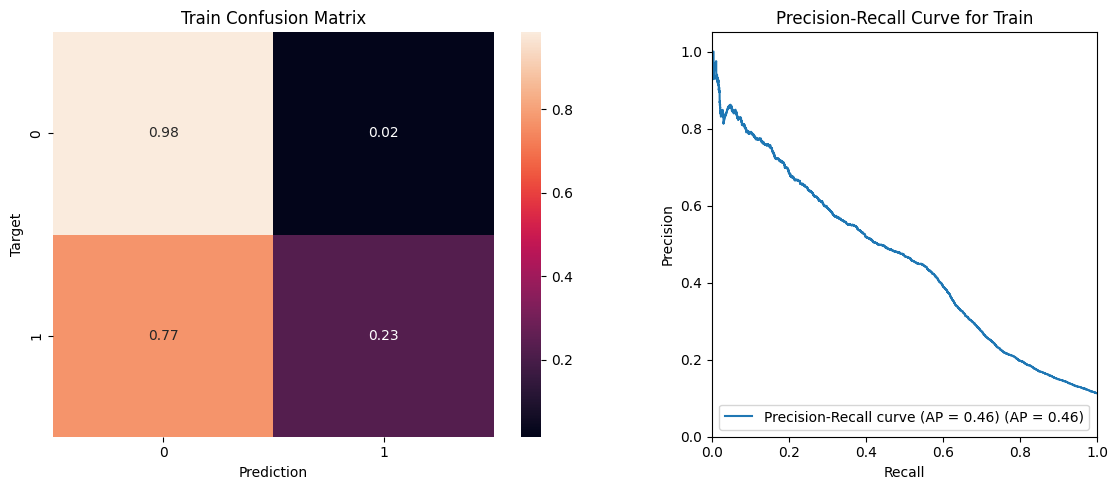

AUROC for Validation: 0.8047
AUCPR for Validation: 0.4677
F1-score for Validation: 0.3412


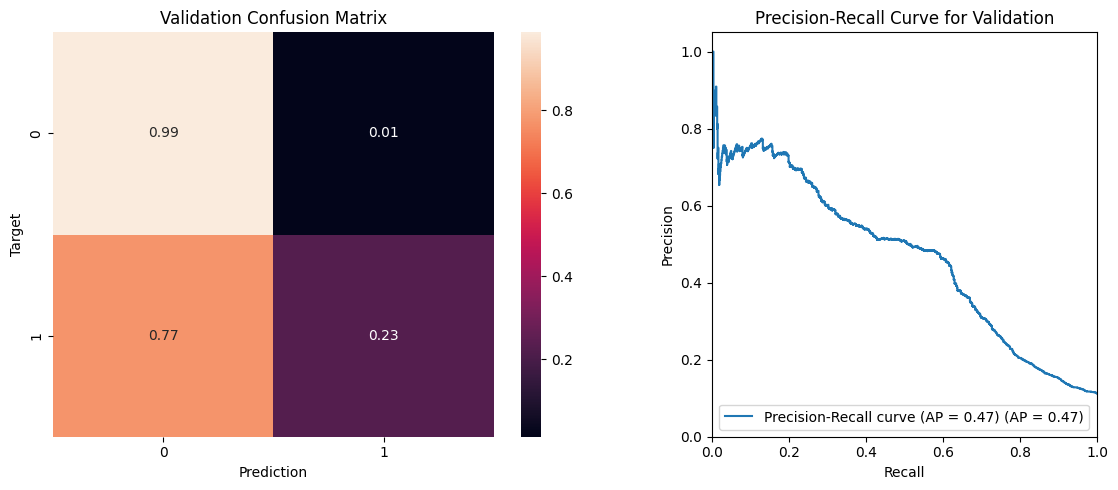

In [ ]:
val_preds = predict_and_plot(model_pipeline_logreg, train_inputs, train_targets, 'Train')
test_preds = predict_and_plot(model_pipeline_logreg, val_inputs, val_targets, 'Validation')

# **KNN model**

AUROC for Train for KNN model: 0.9253
AUCPR for Train for KNN model: 0.5554
F1-score for Train for KNN model: 0.4857


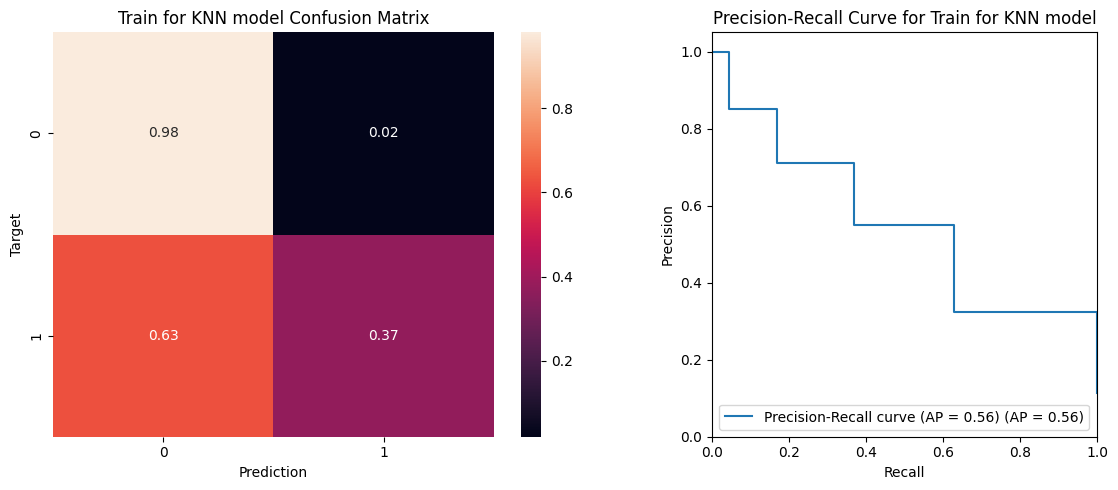

AUROC for Validation for KNN model: 0.7465
AUCPR for Validation for KNN model: 0.3266
F1-score for Validation for KNN model: 0.3601


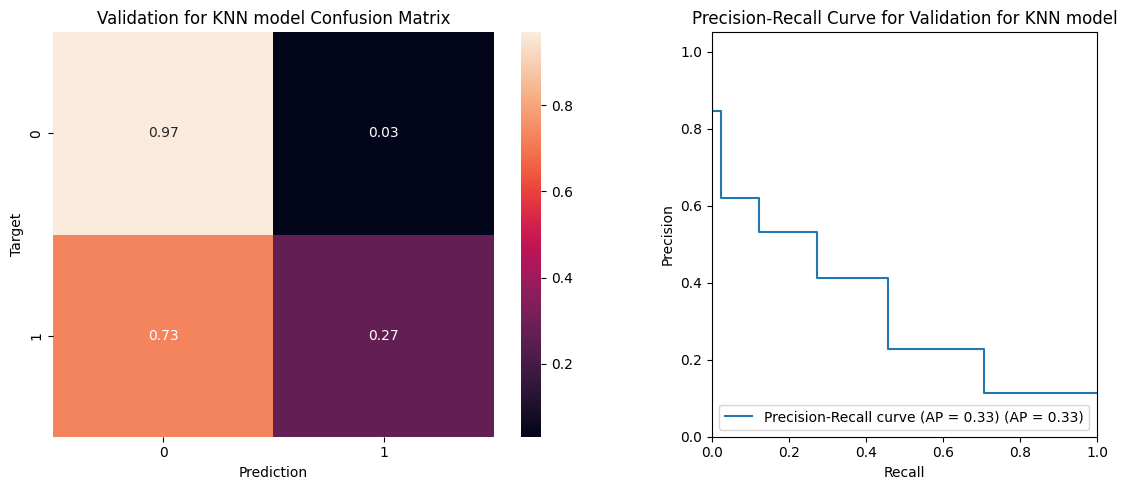

In [ ]:
##Train KNN model
model_pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

model_pipeline_knn.fit(train_inputs, train_targets)

val_preds = predict_and_plot(model_pipeline_knn, train_inputs, train_targets, 'Train for KNN model')
test_preds = predict_and_plot(model_pipeline_knn, val_inputs, val_targets, 'Validation for KNN model')

# **Decision Tree Model**

In [ ]:
def tree_aurpr(md, mln):
  model_pipeline_tree = Pipeline(steps=[
      ('preprocessor', preprocessor),
       ('classifier', DecisionTreeClassifier(
           max_depth=md,
           max_leaf_nodes=mln,
           random_state=42))])


  model_pipeline_tree.fit(train_inputs, train_targets)


  y_pred_proba_train = model_pipeline_tree.predict_proba(train_inputs)[:, 1]
  auprc_train = average_precision_score(train_targets, y_pred_proba_train)

  y_pred_proba_val = model_pipeline_tree.predict_proba(val_inputs)[:, 1]
  auprc_val = average_precision_score(val_targets, y_pred_proba_val)

  return {
        'Max Depth': md,
        'Max Leaf Nodes': mln,
        'AUCPR Train': auprc_train,
        'AUCPR Val': auprc_val
    }

errors_df = pd.DataFrame(
    tree_aurpr(md, mln)
    for md in range(1, 21)
    for mln in range(20, 61, 5)
)

errors_df.style \
    .background_gradient(subset='AUCPR Val', cmap='Blues') \
    .highlight_max(subset='AUCPR Val', color='darkblue')

,Max Depth,Max Leaf Nodes,AUCPR Train,AUCPR Val
0,1,20,0.276958,0.292373
1,1,25,0.276958,0.292373
2,1,30,0.276958,0.292373
3,1,35,0.276958,0.292373
4,1,40,0.276958,0.292373
5,1,45,0.276958,0.292373
6,1,50,0.276958,0.292373
7,1,55,0.276958,0.292373
8,1,60,0.276958,0.292373
9,2,20,0.350556,0.368540


AUROC for Train for Decision Tree model: 0.7933
AUCPR for Train for Decision Tree model: 0.4554
F1-score for Train for Decision Tree model: 0.3497


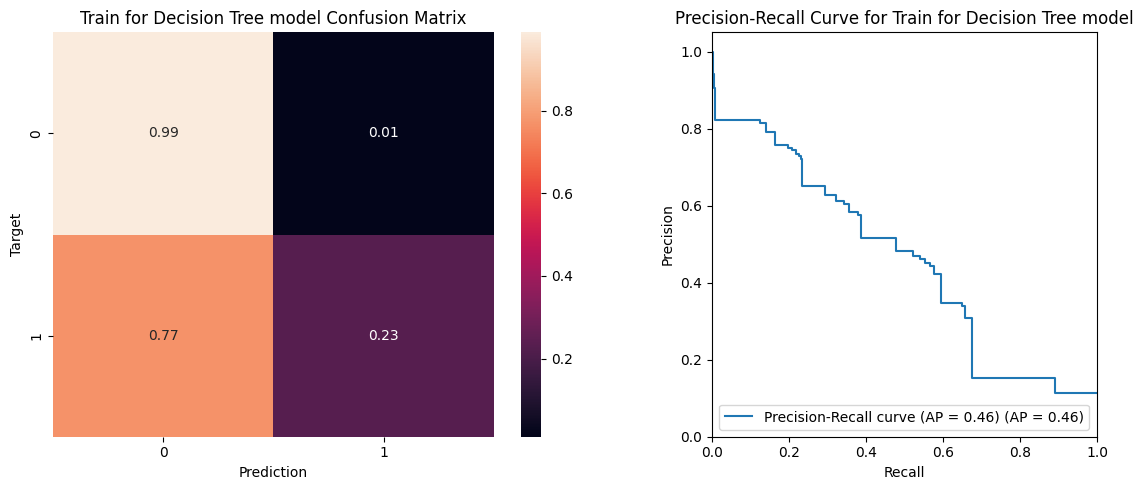

AUROC for Validation for Decision Tree model: 0.7993
AUCPR for Validation for Decision Tree model: 0.4486
F1-score for Validation for Decision Tree model: 0.3369


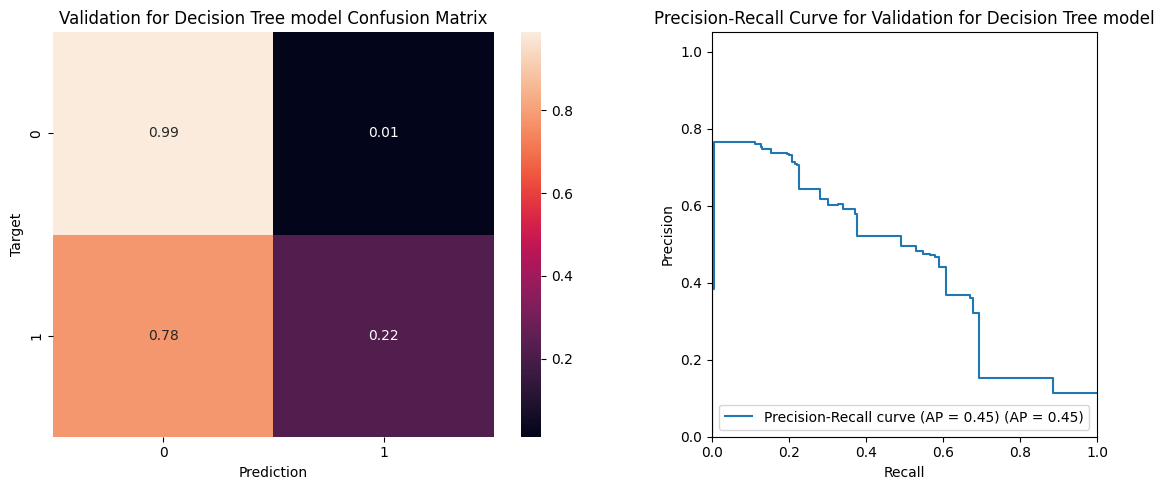

In [ ]:
model_pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('classifier', DecisionTreeClassifier(
           max_depth=6,
           max_leaf_nodes=35,
           random_state=42))])


model_pipeline_tree.fit(train_inputs, train_targets)

val_preds = predict_and_plot(model_pipeline_tree, train_inputs, train_targets, 'Train for Decision Tree model')
test_preds = predict_and_plot(model_pipeline_tree, val_inputs, val_targets, 'Validation for Decision Tree model')

# **LightGBM model with arbitrary parameters**

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2159: UserWarning: cat_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] categorical_feature is set with cat_feature=, categorical_column=1,2,3,4,5,6,7,8,9,13 will be ignored. Current value: categorical_feature=
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 477
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 20
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2159: UserWarning: cat_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

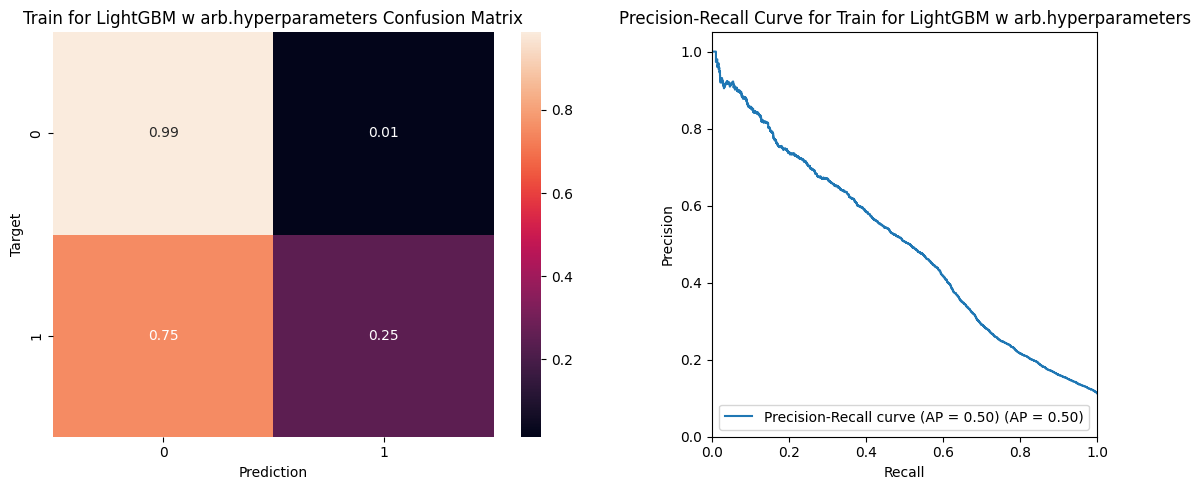

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
AUROC for Validation for LightGBM w arb. hyperparameters: 0.8109
AUCPR for Validation for LightGBM w arb. hyperparameters: 0.4873
F1-score for Validation for LightGBM w arb. hyperparameters: 0.3498


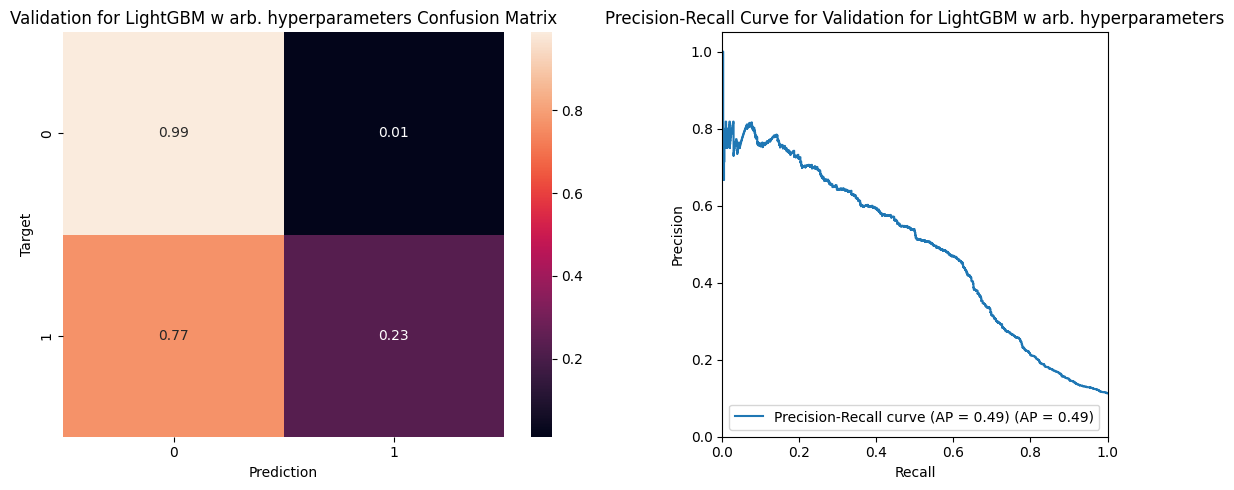

In [ ]:
##LightGBM with arbitrary hyperparameters

cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]

lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
    # device='cuda'  # використовувати GPU для прискорення обчислень
)

lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

val_preds = predict_and_plot(lgb_clf, train_inputs, train_targets, 'Train for LightGBM w arb.hyperparameters')
test_preds = predict_and_plot(lgb_clf, val_inputs, val_targets, 'Validation for LightGBM w arb. hyperparameters')

# **LightGBM model optimized with RandomizedSearchCV**

In [ ]:

# Initialize LGBMClassifier with the identified categorical features
lgbm_clf = lgb.LGBMClassifier(random_state=42, cat_feature=cat_feature_indexes, missing=np.nan)

# Define parameter grid for RandomizedSearchCV for LightGBM
params_lgbm = {
    'n_estimators': [100, 200, 300, 500, 800, 1000],
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves': [2,3, 4, 5, 10, 20, 31, 40, 50, 60], # default is 31
    'max_depth': [1, 2, 3, 5, 7, 9, 11, -1], # -1 means no limit
    'min_child_samples': [20, 30, 40, 50],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 5, 10, 100],
    'reg_lambda': [0, 5, 10, 100],
    'scale_pos_weight': [1, 6, 7, 8, 10]
}

# Setup RandomizedSearchCV
random_search_lgbm = RandomizedSearchCV(estimator=lgbm_clf,
                              param_distributions = params_lgbm,
                              n_iter = 50, # Number of parameter settings that are sampled. Can be increased for more thorough search.
                              cv=3,
                              scoring='average_precision', # Changed to AUCPR (Area Under Precision-Recall Curve)
                              verbose=1,
                              refit = True,
                              n_jobs=-1 # Use all available cores
                              )

# Measure time taken
start_time = time.time()
print("Starting RandomizedSearchCV for LightGBM...")
random_search_lgbm.fit(train_inputs, train_targets)
end_time = time.time()

# Output results
print(f"Time taken for RandomizedSearchCV: {end_time - start_time:.4f} seconds")
print(f"Best parameters: {random_search_lgbm.best_params_}")

# Save the best model
lgbm_random_search_best = random_search_lgbm.best_estimator_

# Evaluate the best model
print(f"\nEvaluating the best LightGBM model found by RandomizedSearchCV...")
# Predictions on training set
train_preds_proba = lgbm_random_search_best.predict_proba(train_inputs)[:, 1]
train_preds = lgbm_random_search_best.predict(train_inputs)
auprc_train = average_precision_score(train_targets, train_preds_proba)
f1_train = f1_score(train_targets, train_preds)
auroc_train = roc_auc_score(train_targets, train_preds_proba)

# Predictions on validation set
val_preds_proba = lgbm_random_search_best.predict_proba(val_inputs)[:, 1]
val_preds = lgbm_random_search_best.predict(val_inputs)
auprc_val = average_precision_score(val_targets, val_preds_proba)
f1_val = f1_score(val_targets, val_preds)
auroc_val = roc_auc_score(val_targets, val_preds_proba)

print(f"\nBest LightGBM Model Performance (RandomizedSearchCV):")
print(f"Train AUROC: {auroc_train:.4f}, Train AUCPR: {auprc_train:.4f}, Train F1-score: {f1_train:.4f}")
print(f"Validation AUROC: {auroc_val:.4f}, Validation AUCPR: {auprc_val:.4f}, Validation F1-score: {f1_val:.4f}")

Starting RandomizedSearchCV for LightGBM...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2159: UserWarning: cat_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] categorical_feature is set with cat_feature=, categorical_column=1,2,3,4,5,6,7,8,9,13 will be ignored. Current value: categorical_feature=
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010363 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 477
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
Time taken for RandomizedSearchCV: 208.7830 seconds
Best parameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 0, 'reg_alpha': 10, 'num_leaves': 4, 'n_estimators': 800, 'min_child_samples': 40, 'max_depth': -1, 'learning_rate': 0.05, 'col

# **LightGBM model with hyperparameters tuned with Bayesian optimization**

In [ ]:
#Bayesian optimization
import lightgbm as lgb
import logging
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import average_precision_score
import numpy as np

# Suppress LightGBM warnings/info messages during Hyperopt runs
logging.getLogger('lightgbm').setLevel(logging.ERROR)

def objective(params):
    # Suppress specific LightGBM warnings that persist
    warnings.filterwarnings('ignore', category=UserWarning, message='.*cat_feature in param dict is overridden.*')
    warnings.filterwarnings('ignore', category=UserWarning, message='.*No further splits with positive gain.*')

    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'] / 100, # Adjust learning rate scale
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_samples=int(params['min_child_samples']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        min_split_gain=params['min_split_gain'],
        scale_pos_weight=params['scale_pos_weight'], # Added parameter
        max_bin=int(params['max_bin']), # Added parameter
        random_state=42,
        n_jobs=-1,
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        eval_metric='aucpr',
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
        categorical_feature=cat_feature_indexes
    )

    if clf.best_iteration_ is not None:
        y_pred_proba_val_current = clf.predict_proba(val_inputs, num_iteration=clf.best_iteration_)[:, 1]
    else:
        y_pred_proba_val_current = clf.predict_proba(val_inputs)[:, 1]

    auprc = average_precision_score(val_targets, y_pred_proba_val_current)

    return {'loss': -auprc, 'status': STATUS_OK}

# Suggested search space adjustments to mitigate overfitting and explore more effectively
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 3000, 50),
    'learning_rate': hp.uniform('learning_rate', 0.5, 10), # Search for percentage, will divide by 100 in objective
    'max_depth': hp.quniform('max_depth', 1, 8, 1),
    'num_leaves': hp.quniform('num_leaves', 2, 70, 1),
    'min_child_samples': hp.quniform('min_child_samples', 80, 150, 10),
    'subsample': hp.uniform('subsample', 0.6, 0.9),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 0.9),
    'reg_alpha': hp.uniform('reg_alpha', 0, 150),
    'reg_lambda': hp.uniform('reg_lambda', 0, 150),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.2),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10), # Add scale_pos_weight, roughly neg/pos ratio
    'max_bin': hp.quniform('max_bin', 31, 255, 32) # Add max_bin
}

trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=200, trials=trials) # Increased max_evals to 200

# Convert best hyperparameters to final types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_samples'] = int(best['min_child_samples'])
best['max_bin'] = int(best['max_bin'])

# Adjust learning_rate back to original scale (was percentage in search space)
best['learning_rate'] = best['learning_rate'] / 100

print("Найкращі гіперпараметри: ", best)

# Train the final model with the best hyperparameters, using early stopping
final_clf_hyperopt = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_samples=best['min_child_samples'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    scale_pos_weight=best['scale_pos_weight'],
    max_bin=best['max_bin'],
    random_state=42,
    n_jobs=-1,
)

final_clf_hyperopt.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    eval_metric='aucpr',
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    categorical_feature=cat_feature_indexes
)

# Evaluate the final model using the best iteration from early stopping
if final_clf_hyperopt.best_iteration_ is not None:
    final_pred_proba_val = final_clf_hyperopt.predict_proba(val_inputs, num_iteration=final_clf_hyperopt.best_iteration_)[:, 1]
    final_pred_proba_train = final_clf_hyperopt.predict_proba(train_inputs, num_iteration=final_clf_hyperopt.best_iteration_)[:, 1]
else:
    final_pred_proba_val = final_clf_hyperopt.predict_proba(val_inputs)[:, 1]
    final_pred_proba_train = final_clf_hyperopt.predict_proba(train_inputs)[:, 1]

auprc_val = average_precision_score(val_targets, final_pred_proba_val)
auprc_train = average_precision_score(train_targets, final_pred_proba_train)
print("AUPRC on train data (Hyperopt Bayesian Optimization): {:.4f}".format(auprc_train))
print("AUPRC on val data (Hyperopt Bayesian Optimization): {:.4f}".format(auprc_val))

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

## Model Performance Comparison

| Model Name                             | Hyperparameters                                                                                                                                                                                                                                                                                              | Training Time | Train AUCPR | Validation AUCPR | Comment                                                                                                                                                                                                                                                                                                                                       |
| :------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :---------------- | :---------- | :--------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Logistic Regression**                  | `solver='liblinear'`, `random_state=42`                                                                                                                                                                                                                                                                                      | 5s               | 0.4582      | 0.4677           | A solid baseline model. Its performance on training and validation sets is very close, indicating good generalization and no obvious overfitting. It serves as a good benchmark for more complex models.                                                                                                                                                                        |
| **k-Nearest Neighbors (k-NN)**           | Default (`n_neighbors=5`)                                                                                                                                                                                                                                                                                                    | 44s               | 0.5554      | 0.3266           | Shows clear signs of overfitting, with a much higher AUCPR on the training set compared to the validation set. This suggests the model is memorizing the training data. Further tuning or a different approach is needed for better generalization.                                                                                                                            |
| **Best Decision Tree**                   | `max_depth=6`, `max_leaf_nodes=35`, `random_state=42`                                                                                                                                                                                                                                                                        | 3mins               | 0.4554      | 0.4486           | Provides a reasonable balance and better generalization than k-NN, performing comparably to Logistic Regression. It's highly interpretable, which can be valuable for understanding feature interactions.                                                                                                                                                            |
| **LightGBM (Arbitrary Hyperparameters)** | `max_depth=3`, `n_estimators=100`, `learning_rate=0.1`, `cat_feature=cat_feature_indexes`, `missing=np.nan`                                                                                                                                                                                                                  | 3s               | 0.4686      | 0.4686           | Demonstrates strong and balanced performance right out of the box, with very similar AUCPR on both training and validation sets. This indicates good generalization and robust learning, showing its potential before extensive tuning.                                                                                                                           |
| **LightGBM (Random Search)**             | `subsample=1.0`, `scale_pos_weight=1`, `reg_lambda=0`, `reg_alpha=10`, `num_leaves=4`, `n_estimators=800`, `min_child_samples=40`, `max_depth=-1`, `learning_rate=0.05`, `colsample_bytree=0.6`                                                                                                                                     | 3min            | 0.4943      | 0.4856           | Achieved a significant improvement over the arbitrary LightGBM parameters, demonstrating the value of hyperparameter tuning. The scores are well-balanced, suggesting a good trade-off between bias and variance.                                                                                                                                                      |
| **LightGBM (Bayesian Optimization)**     | `colsample_bytree=0.8959`, `learning_rate=0.0392`, `max_bin=160`, `max_depth=6`, `min_child_samples=90`, `min_split_gain=0.0767`, `n_estimators=1950`, `num_leaves=61`, `reg_alpha=7.9481`, `reg_lambda=130.48`, `scale_pos_weight=1.7806`, `subsample=0.6556` (Approx. 200 evaluations for fmin) | 1hour      | 0.5125      | 0.5002           | Achieved the highest validation AUCPR among all tested models, showcasing the effectiveness of Bayesian optimization in finding a near-optimal set of hyperparameters. The performance is robust, with a good balance between training and validation scores. This model represents the best performance found so far.

# **Feature importance analysis for the best model (LightGBM (Bayesian Optimization))**

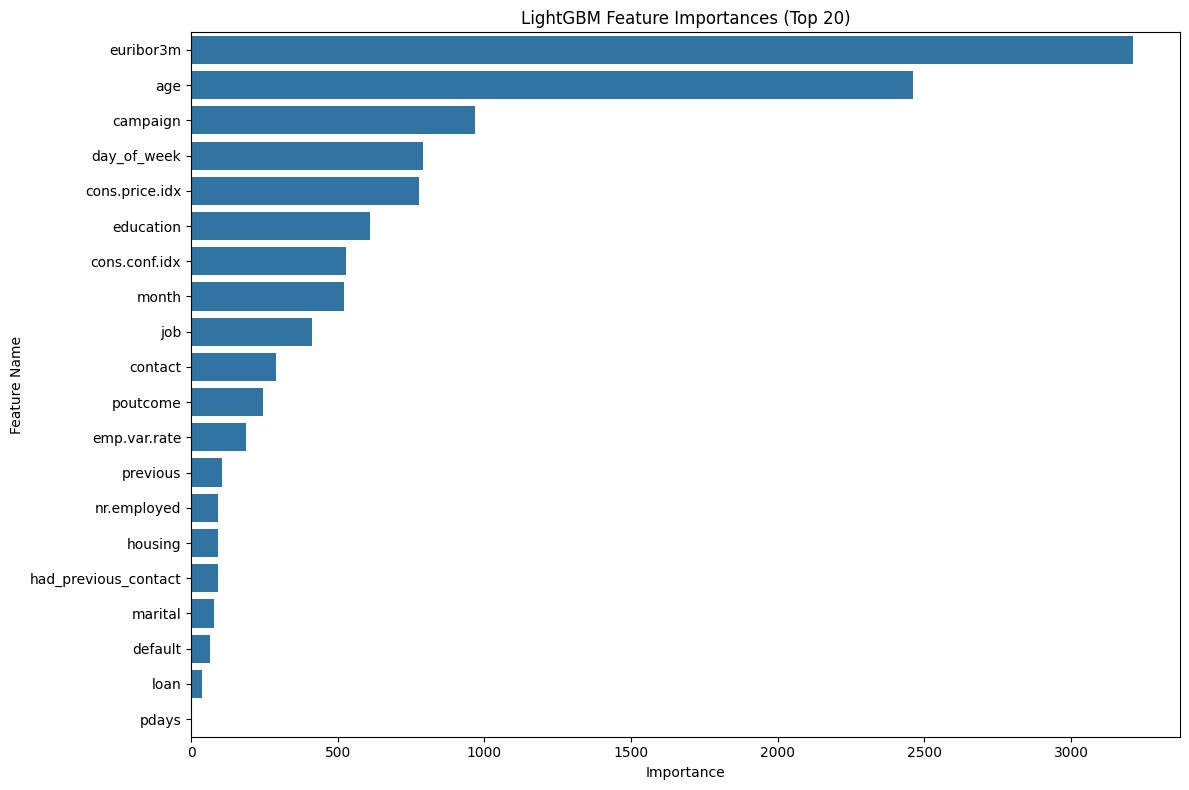

In [ ]:
best_model = final_clf_hyperopt

##Feature importance from the model

# Get feature importances from the trained LightGBM model
feature_importances = best_model.feature_importances_

# Get feature names from the processed training data
feature_names = train_inputs.columns.tolist()

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('LightGBM Feature Importances (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [ ]:
# import shap library
!pip install shap
import shap

# create object for explaining model predictions with SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(train_inputs)

# visualize the explanation of the first row forecast
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], train_inputs.iloc[0,:])

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
train_inputs.iloc[0,:]

,25611
age,49
job,blue-collar
marital,married
education,basic.9y
default,unknown
housing,no
loan,no
contact,cellular
month,nov
day_of_week,wed


In [ ]:
sample_size = 500
subset_indices = np.random.choice(train_inputs.shape[0], sample_size, replace=False)

# Create subset of SHAP values
shap_values_subset = shap_values[subset_indices]
train_inputs_subset = train_inputs.iloc[subset_indices]

# Visualization for the subset
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values_subset, train_inputs_subset)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


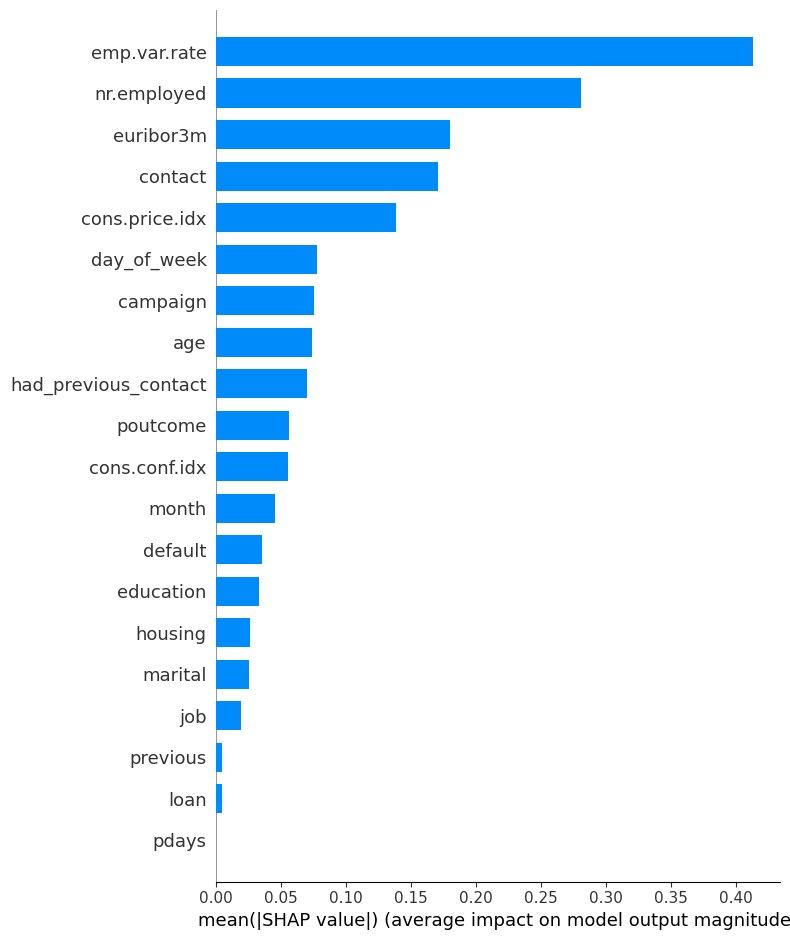

In [ ]:
shap_values = shap.TreeExplainer(best_model).shap_values(train_inputs)  # Shap values calculation
shap.summary_plot(shap_values, train_inputs, plot_type="bar")  # Create summary shap values chart

### Detailed Feature Importance Analysis for the Best Model (LightGBM - Bayesian Optimization)

Both LightGBM's built-in `feature_importances_` and SHAP values (`shap.summary_plot`) provide insights into feature importance, albeit from different perspectives. LightGBM's `feature_importances_` (`Importance_df`) generally reflects how often a feature is used for splits or the gain it provides across the trees. SHAP values, on the other hand, explain how much each feature contributes to pushing the model's output from the average prediction to the current prediction, offering a more nuanced understanding of prediction impact.

Combining insights from both and our EDA:

1.  **`euribor3m` (Euro Interbank Offered Rate 3 months)**:
    *   **High Importance (both methods)**: This is consistently identified as the most crucial feature. Its high importance is understandable as economic indicators heavily influence financial decisions.
    *   **EDA Insight**: Our EDA showed `euribor3m` is significantly lower for subscribers (mean: 2.14) than for non-subscribers (mean: 3.81). This suggests that lower interest rates make term deposits more attractive, making this a critical factor in the subscription decision.

2.  **`age`**:
    *   **High Importance**: Age is another highly influential feature.
    *   **EDA Insight**: Subscribers had a slightly higher median age, indicating a subtle but consistent trend.

3.  **`campaign` (Number of contacts during this campaign)**:
    *   **High Importance**: `campaign` is a very important feature.
    *   **EDA Insight**: Clients who subscribed generally had fewer contacts (mean: 2.06) than those who did not (mean: 2.61). This reinforces the idea that excessive campaigning can be counterproductive, and successful conversions often happen earlier.

4.  **`day_of_week`**:
    *   **Significant Importance**: While month had a strong impact, the day of the week also plays a role.
    *   **EDA Insight**: The `day_of_week` showed less pronounced impact compared to `month` in the initial EDA, with rates relatively similar across days. However, the model finds granular patterns here that contribute to the prediction.

5.  **`cons.price.idx` (Consumer Price Index)**:
    *   **High Importance**: Another key economic indicator influencing decisions.
    *   **EDA Insight**: This feature showed subtle differences between subscribers and non-subscribers, indicating its relevance to economic stability and consumer confidence.

6.  **`month` (Last contact month of year)**:
    *   **Significant Importance**: This was clearly very important in our EDA.
    *   **EDA Insight**: Months like `mar`, `sep`, `oct`, and `dec` had significantly higher subscription rates (30-40%), while `may`, `jun`, `jul`, and `aug` had much lower rates. The model has learned to leverage these seasonal patterns.

7.  **`education`**:
    *   **Moderate Importance**: Education level impacts subscription likelihood.
    *   **EDA Insight**: Clients with `university.degree` and `professional.course` had higher subscription rates (13-14%) compared to `basic` education levels, which the model uses to differentiate customers.

8.  **`contact` (Contact communication type)**:
    *   **Moderate Importance**: The method of contact is important.
    *   **EDA Insight**: `cellular` contact was much more effective (14% subscription rate) than `telephone` (5%), suggesting modern direct communication channels are more successful and the model captures this.

9.  **`poutcome` (Outcome of the previous marketing campaign)**:
    *   **Moderate Importance**: This is a strong predictor.
    *   **EDA Insight**: `success` in a previous campaign led to an extremely high subscription rate (~65%), making this a very powerful indicator for the model. `nonexistent` and `failure` had very low rates.

10. **`job` (Type of job)**:
    *   **Moderate Importance**: Job type plays a role.
    *   **EDA Insight**: `student` and `retired` categories showed significantly higher subscription rates (30-31%), while `blue-collar` and `services` had the lowest, influencing the model's predictions.

11. **`marital` (Marital status)**:
    *   **Lower Importance**: Still contributes to the model's decision.
    *   **EDA Insight**: `single` individuals had a higher subscription rate (14%) compared to `married` (10%) and `divorced` (~0%).

12. **`default` (Has credit in default?)**:
    *   **Lower Importance**: This feature has a strong signal but its `unknown` values make it tricky.
    *   **EDA Insight**: Clients with `no` default had a significantly higher subscription rate. The `unknown` status also correlated with a low subscription rate, similar to `yes` default. The model likely learned to treat `unknown` similarly to `yes` or found patterns within the known categories.

13. **`cons.conf.idx` (Consumer Confidence Index)**:
    *   **Lower Importance**: Another economic indicator, though less impactful than `euribor3m` or `cons.price.idx`.
    *   **EDA Insight**: `cons.conf.idx` was slightly higher for subscribers, suggesting more optimistic consumers are more likely to convert.

14. **`previous` (Number of contacts performed before this campaign)**:
    *   **Lower Importance**: Previous interactions have some influence.
    *   **EDA Insight**: Subscribers had a higher mean number of previous contacts (0.49) compared to non-subscribers (0.15), indicating previous engagement can be positive.

15. **`nr.employed` (Number of employees)**:
    *   **Lower Importance**: This social and economic attribute contributes to predictions.
    *   **EDA Insight**: While not explicitly detailed in the provided EDA for its distribution with `y`, `nr.employed` is a macroeconomic indicator that can reflect overall economic conditions and job market stability, which are relevant to consumer financial decisions.

16. **`pdays` (Days since last contact from a previous campaign)**:
    *   **Lower Importance**: This feature is important, especially considering the `999` value.
    *   **EDA Insight**: Lower `pdays` (excluding 999) correlated with higher subscription. The model has learned to interpret the `999` (no previous contact) versus actual days since contact.

17. **`loan` (Has personal loan?)** and **`housing` (Has housing loan?)**:
    *   **Very Low Importance**: These features showed minimal impact.
    *   **EDA Insight**: Neither `housing` nor `loan` showed a strong difference in subscription rates between 'yes' and 'no' categories in the EDA, which is consistent with their low feature importance in the model.

18. **`emp.var.rate` (Employment Variation Rate)**:
    *   **Very Low Importance**: Another economic indicator, though with minimal influence on the final model.
    *   **EDA Insight**: Subscribers tended to be associated with a lower `emp.var.rate`, suggesting higher likelihood during periods of lower economic uncertainty. While relevant, its relative importance here is low compared to `euribor3m`.

# **Find threshold probability value for marketing campaigh**

Found thresholds where Precision and Recall are between 0.4 and 0.6:
     threshold  precision  recall  f1_score
79      0.3797     0.4986  0.5819    0.5370
78      0.3796     0.4982  0.5819    0.5368
77      0.3794     0.4977  0.5819    0.5365
94      0.3833     0.5014  0.5765    0.5363
80      0.3802     0.4982  0.5808    0.5363
..         ...        ...     ...       ...
506     0.5221     0.5781  0.4030    0.4749
505     0.5209     0.5772  0.4030    0.4746
507     0.5221     0.5774  0.4019    0.4740
509     0.5226     0.5776  0.4009    0.4733
508     0.5225     0.5767  0.4009    0.4730

[510 rows x 4 columns]

Suggested threshold for desired range (max F1 in range): 0.3797
  Precision: 0.4986
  Recall: 0.5819
  F1-Score: 0.5370


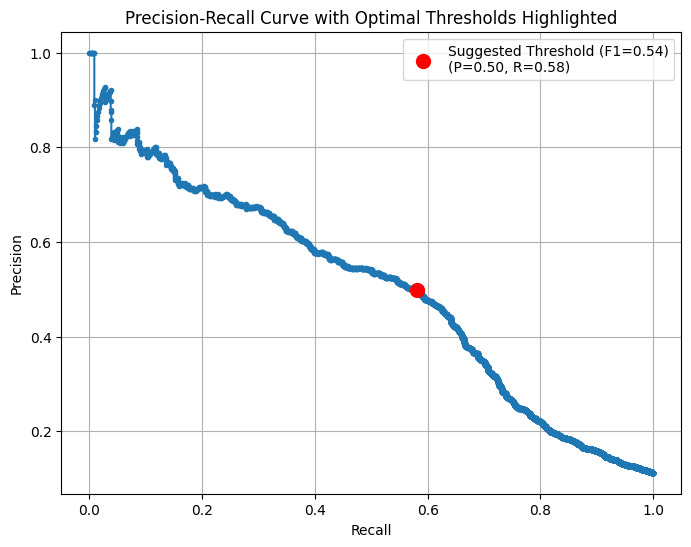

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the validation set
# Assuming val_inputs and val_targets are already defined and hold the preprocessed validation data and actual labels
val_preds_proba = best_model.predict_proba(val_inputs)[:, 1]

# Calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(val_targets, val_preds_proba)

# Find thresholds where both precision and recall are between 0.4 and 0.6
optimal_thresholds = []
for i in range(len(thresholds)):
    if 0.4 <= precision[i] <= 0.6 and 0.4 <= recall[i] <= 0.6:
        optimal_thresholds.append({
            'threshold': thresholds[i],
            'precision': precision[i],
            'recall': recall[i],
            'f1_score': f1_score(val_targets, (val_preds_proba >= thresholds[i]).astype(int))
        })

if optimal_thresholds:
    print("Found thresholds where Precision and Recall are between 0.4 and 0.6:")
    # Sort by F1-score to suggest the best balance, or pick one with a good balance
    optimal_thresholds_df = pd.DataFrame(optimal_thresholds).sort_values(by='f1_score', ascending=False)
    print(optimal_thresholds_df.round(4))

    # Let's pick the threshold that maximizes F1-score within the given range
    best_threshold_in_range = optimal_thresholds_df.iloc[0]
    print(f"\nSuggested threshold for desired range (max F1 in range): {best_threshold_in_range['threshold']:.4f}")
    print(f"  Precision: {best_threshold_in_range['precision']:.4f}")
    print(f"  Recall: {best_threshold_in_range['recall']:.4f}")
    print(f"  F1-Score: {best_threshold_in_range['f1_score']:.4f}")

    # Plotting the Precision-Recall curve with the suggested threshold
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='.')
    plt.scatter(best_threshold_in_range['recall'], best_threshold_in_range['precision'],
                color='red', s=100, zorder=5,
                label=f"Suggested Threshold (F1={best_threshold_in_range['f1_score']:.2f})\n(P={best_threshold_in_range['precision']:.2f}, R={best_threshold_in_range['recall']:.2f})")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Optimal Thresholds Highlighted')
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("No single threshold found where both Precision and Recall are between 0.4 and 0.6.")
    print("Plotting the full Precision-Recall curve for reference.")
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid(True)
    plt.show()

# **False Positives/ False Negatives Analysis**

In [ ]:
preds_val = best_model.predict(val_inputs)
preds_proba_val = best_model.predict_proba(val_inputs)[:, 1]

# Create a DataFrame for easier analysis, including the original features
results_df = val_inputs.copy()
results_df['target'] = val_targets
results_df['prediction'] = preds_val
results_df['probability'] = preds_proba_val

# Identify misclassifications
false_negatives = results_df[(results_df['target'] == 1) & (results_df['prediction'] == 0)]
false_positives = results_df[(results_df['target'] == 0) & (results_df['prediction'] == 1)]

print(f"Total validation samples: {len(results_df)}")
print(f"False Negatives (Actual: Yes, Predicted: No): {len(false_negatives)}")
print(f"False Positives (Actual: No, Predicted: Yes): {len(false_positives)}")

print("\n### --- Analysis of False Negatives (Missed Opportunities) ---")
print("#### Descriptive statistics for numerical features in False Negatives:")
display(false_negatives.select_dtypes(include=['number']).describe().round(2))
print("\n#### Top categorical feature distributions in False Negatives:")
for col in categorical_cols: # Assuming categorical_cols is defined from earlier
    print(f"##### '{col}' Distribution in False Negatives:")
    display(false_negatives[col].value_counts(normalize=True).round(2).to_frame(name='proportion'))

print("\n### --- Analysis of False Positives (Wasted Resources) ---")
print("#### Descriptive statistics for numerical features in False Positives:")
display(false_positives.select_dtypes(include=['number']).describe().round(2))
print("\n#### Top categorical feature distributions in False Positives:")
for col in categorical_cols: # Assuming categorical_cols is defined from earlier
    print(f"##### '{col}' Distribution in False Positives:")
    display(false_positives[col].value_counts(normalize=True).round(2).to_frame(name='proportion'))

Total validation samples: 8238
False Negatives (Actual: Yes, Predicted: No): 530
False Positives (Actual: No, Predicted: Yes): 309

### --- Analysis of False Negatives (Missed Opportunities) ---
#### Descriptive statistics for numerical features in False Negatives:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,had_previous_contact,target,prediction,probability
count,530.00,530.00,530.00,530.0,530.00,530.00,530.00,530.00,530.00,530.00,530.0,530.0,530.00
mean,40.11,2.34,6.07,0.2,-0.68,93.32,-40.85,2.83,5139.91,0.02,1.0,0.0,0.22
std,11.87,2.05,0.58,0.5,1.76,0.62,5.54,1.84,74.84,0.14,0.0,0.0,0.16
min,18.00,1.00,5.00,0.0,-3.40,92.20,-50.80,0.64,4963.60,0.00,1.0,0.0,0.03
25%,31.00,1.00,6.00,0.0,-1.80,92.89,-46.20,1.26,5099.10,0.00,1.0,0.0,0.09
50%,37.00,2.00,6.00,0.0,-1.80,93.08,-42.00,1.42,5099.10,0.00,1.0,0.0,0.14
75%,47.00,3.00,6.00,0.0,1.40,93.92,-36.40,4.96,5228.10,0.00,1.0,0.0,0.39
max,85.00,17.00,12.00,4.0,1.40,94.77,-26.90,4.97,5228.10,1.00,1.0,0.0,0.50



#### Top categorical feature distributions in False Negatives:
##### 'job' Distribution in False Negatives:


,proportion
job,
admin.,0.28
blue-collar,0.19
technician,0.15
services,0.09
management,0.07
retired,0.06
self-employed,0.04
entrepreneur,0.04
student,0.03


##### 'marital' Distribution in False Negatives:


,proportion
marital,
married,0.57
single,0.31
divorced,0.12
unknown,0.00


##### 'education' Distribution in False Negatives:


,proportion
education,
university.degree,0.32
high.school,0.24
basic.9y,0.15
professional.course,0.13
basic.4y,0.08
basic.6y,0.04
unknown,0.04
illiterate,0.00


##### 'default' Distribution in False Negatives:


,proportion
default,
no,0.86
unknown,0.14


##### 'housing' Distribution in False Negatives:


,proportion
housing,
yes,0.56
no,0.42
unknown,0.01


##### 'loan' Distribution in False Negatives:


,proportion
loan,
no,0.88
yes,0.11
unknown,0.01


##### 'contact' Distribution in False Negatives:


,proportion
contact,
cellular,0.76
telephone,0.24


##### 'month' Distribution in False Negatives:


,proportion
month,
may,0.31
jul,0.18
aug,0.15
apr,0.12
jun,0.11
nov,0.08
oct,0.02
sep,0.02
mar,0.01


##### 'day_of_week' Distribution in False Negatives:


,proportion
day_of_week,
thu,0.22
wed,0.21
fri,0.20
tue,0.19
mon,0.18


##### 'poutcome' Distribution in False Negatives:


,proportion
poutcome,
nonexistent,0.83
failure,0.15
success,0.02



### --- Analysis of False Positives (Wasted Resources) ---
#### Descriptive statistics for numerical features in False Positives:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,had_previous_contact,target,prediction,probability
count,309.00,309.00,309.00,309.00,309.00,309.00,309.00,309.00,309.00,309.00,309.0,309.0,309.00
mean,42.27,1.83,6.15,0.54,-2.30,93.17,-38.46,1.04,5040.85,0.24,0.0,1.0,0.62
std,17.35,1.25,1.94,0.88,0.79,0.68,6.94,0.54,47.87,0.43,0.0,0.0,0.10
min,17.00,1.00,1.00,0.00,-3.40,92.20,-50.80,0.64,4963.60,0.00,0.0,1.0,0.50
25%,29.00,1.00,6.00,0.00,-2.90,92.65,-40.80,0.72,5008.70,0.00,0.0,1.0,0.54
50%,35.00,1.00,6.00,0.00,-1.80,92.96,-39.80,0.88,5017.50,0.00,0.0,1.0,0.59
75%,54.00,2.00,6.00,1.00,-1.80,93.88,-33.00,1.27,5076.20,0.00,0.0,1.0,0.68
max,95.00,13.00,19.00,5.00,-0.10,94.77,-26.90,4.92,5195.80,1.00,0.0,1.0,0.90



#### Top categorical feature distributions in False Positives:
##### 'job' Distribution in False Positives:


,proportion
job,
admin.,0.31
retired,0.16
technician,0.15
student,0.08
management,0.07
blue-collar,0.06
services,0.03
entrepreneur,0.03
self-employed,0.03


##### 'marital' Distribution in False Positives:


,proportion
marital,
married,0.47
single,0.45
divorced,0.08
unknown,0.00


##### 'education' Distribution in False Positives:


,proportion
education,
university.degree,0.46
high.school,0.19
professional.course,0.12
basic.4y,0.11
basic.9y,0.06
unknown,0.05
basic.6y,0.02
illiterate,0.00


##### 'default' Distribution in False Positives:


,proportion
default,
no,0.98
unknown,0.02


##### 'housing' Distribution in False Positives:


,proportion
housing,
yes,0.50
no,0.46
unknown,0.04


##### 'loan' Distribution in False Positives:


,proportion
loan,
no,0.82
yes,0.14
unknown,0.04


##### 'contact' Distribution in False Positives:


,proportion
contact,
cellular,0.96
telephone,0.04


##### 'month' Distribution in False Positives:


,proportion
month,
jun,0.17
mar,0.13
apr,0.12
oct,0.10
aug,0.10
nov,0.09
may,0.08
jul,0.08
sep,0.07


##### 'day_of_week' Distribution in False Positives:


,proportion
day_of_week,
tue,0.24
thu,0.24
wed,0.20
fri,0.18
mon,0.14


##### 'poutcome' Distribution in False Positives:


,proportion
poutcome,
nonexistent,0.64
success,0.21
failure,0.15


## Recommendations for Model Improvement and Campaign Optimization

1.  **Cost-Sensitive Learning**: Explicitly integrate the real-world business costs of misclassification into the model's training. This can be done by:
    *   **Adjusting `scale_pos_weight`**: In LightGBM, fine-tune `scale_pos_weight` (which was explored in Bayesian optimization) based on the estimated cost of a False Negative (FN) versus a False Positive (FP). For example, if a false negative costs 5 times more than a false positive, set the weight accordingly.
    *   **Custom Loss Functions**: If using models that support it, define a custom loss function that incorporates a cost matrix, directly penalizing FNs and FPs differently during training.

2.  **Explore Advanced Ensemble Methods**: Beyond the current LightGBM setup, consider more sophisticated ensemble techniques:
    *   **Stacking**: Combine predictions from different types of base models (e.g., Logistic Regression, Decision Tree, and LightGBM) using a meta-learner (e.g., another Logistic Regression or a simple neural network) to make the final prediction.
    *   **Blending**: Similar to stacking, but uses a hold-out set for training the meta-learner to reduce overfitting.
    *   **Other Boosting Algorithms**: Experiment with XGBoost or CatBoost, which might offer different strengths and potentially better performance on this dataset.

3.  **Dynamic Thresholding**: Instead of relying on a single static probability threshold (0.3797), explore dynamic thresholding strategies:
    *   **Segment-Specific Thresholds**: Analyze if different customer segments (e.g., based on `job` or `age`) respond differently and could benefit from customized thresholds.
    *   **A/B Testing**: Implement A/B testing in actual campaigns to evaluate the impact of slightly varied thresholds on conversion rates and marketing costs.
    *   **Business Objective-Driven**: Continuously adjust the threshold based on current business objectives – for example, a higher recall threshold if the goal is aggressive growth, or a higher precision threshold if the goal is cost efficiency.